# Analyzing and Plotting ProbCOPA Results from Models (including Model-Human Comparisons)

This notebook includes the code used to run statistical tests on the model results for ProbCOPA, as well as generate the plots presented in the paper. Before running this notebook, make sure you remove the canary strings from any files containing the actual human annotations, by running the following lines of code:

```
python scripts/remove_canary_strings.py --input-filepath "datasets/probcopa_CANARY.jsonl" --output-filepath "datasets/probcopa.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_human_results_annotated_CANARY.jsonl" --output-filepath "results/probcopa_human_results_annotated.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_random_sample_prompt_validation_round_human_results_CANARY.jsonl" --output-filepath "results/probcopa_random_sample_prompt_validation_round_human_results_cleaned.jsonl"
python scripts/remove_canary_strings.py --input-filepath "results/probcopa_random_sample_validation_round_human_results_CANARY.jsonl" --output-filepath "results/probcopa_random_sample_validation_round_human_results_cleaned.jsonl"
```

## Import libraries and read in data:

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os 
import json
import itertools
from tqdm import tqdm


In [198]:
models = ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']
model_results_paths = {model: f"./results/probcopa_{model}.jsonl" for model in models}

model_results = {}
for model, path in model_results_paths.items():
    data = pd.read_json(path, lines=True)
    data['source'] = model
    data['type'] = 'model'
    model_results[model] = data
    if 'reasoning_token_count' in model_results[model].columns:
        model_results[model]['reasoning_token_count'] = model_results[model]['reasoning_token_count'].apply(lambda x: float(x))
        model_results[model]['reasoning_chain_length'] = pd.to_numeric(model_results[model]['reasoning_token_count'], errors='coerce').fillna(0).astype(int)
    else:
        model_results[model]['reasoning_token_count'] = None # Just to prevent errors


## Annotate the model responses for things like differential entropy:

In [199]:
def attempt_digit_conversion(x):
    try:
        output = float(x)
    except:
        output = None
    return output


def estimate_differential_entropy(x, sigma=0.1, random_seed=3535):
    np.random.seed(random_seed)
    random_noise = np.random.normal(0, sigma, len(x))
    x_with_noise = x + random_noise
    x_with_noise = x_with_noise[~np.isnan(x_with_noise)]
    return stats.differential_entropy(x_with_noise)


In [200]:
for model in models:
    model_results[model]['response'] = model_results[model]['answer'].apply(attempt_digit_conversion)
    model_results[model]['median_response'] = model_results[model].groupby(['UID'])['response'].transform('median')
    model_results[model]['mean_response'] = model_results[model].groupby(['UID'])['response'].transform('mean')
    model_results[model]['std_response'] = model_results[model].groupby(['UID'])['response'].transform('std')
    model_results[model]['diff_entropy_response'] = model_results[model].groupby(['UID'])['response'].transform(estimate_differential_entropy)


/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)


In [201]:
joint_model_results = pd.concat(model_results.values()).reset_index(drop=True)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/196196603.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  joint_model_results = pd.concat(model_results.values()).reset_index(drop=True)


## Reading in human results and connecting them with model results:

In [202]:
human_results_path = "./results/probcopa_human_results_annotated.jsonl"
human_results = pd.read_json(human_results_path, lines=True)
human_results['source'] = 'human'
human_results['type'] = 'human'

joint_results = pd.concat([joint_model_results, human_results]).reset_index(drop=True)

In [203]:
# Add human validation results as well, annotate them:

human_validation_results_path = "./results/probcopa_random_sample_validation_round_human_results_cleaned.jsonl"
human_validation_results = pd.read_json(human_validation_results_path, lines=True)

human_validation_results['type'] = 'human'
human_validation_results['marginal_time'] = human_validation_results.groupby('workerid')['time'].transform('diff')
human_validation_results['marginal_time'] = human_validation_results['marginal_time'] * 60 # Make it in seconds
human_validation_results['marginal_time_log'] = human_validation_results['marginal_time'].apply(lambda x: np.log(x) if not np.isnan(x) else np.nan)
human_validation_results['marginal_time_zscored'] = human_validation_results.groupby('workerid')['marginal_time'].transform(lambda x: (x - x.mean()) / x.std())
human_validation_results['marginal_time_log_zscored'] = human_validation_results.groupby('workerid')['marginal_time_log'].transform(lambda x: (x - x.mean()) / x.std())

human_validation_results['median_response'] = human_validation_results.groupby('UID')['response'].transform('median')
human_validation_results['mean_response'] = human_validation_results.groupby('UID')['response'].transform('mean')
human_validation_results['std_response'] = human_validation_results.groupby('UID')['response'].transform('std')

human_validation_results['diff_entropy_response'] = human_validation_results.groupby('UID')['response'].transform(estimate_differential_entropy)

human_validation_results['source'] = 'Human Baseline (Random Sample)'
human_validation_results['type'] = 'Human Baseline (Random Sample)'


## Looking at models vs humans for a random sample:

Premise: The leader antagonized the extremists among his country.
Hypothesis: The extremists influenced him.
Asks-for: effect


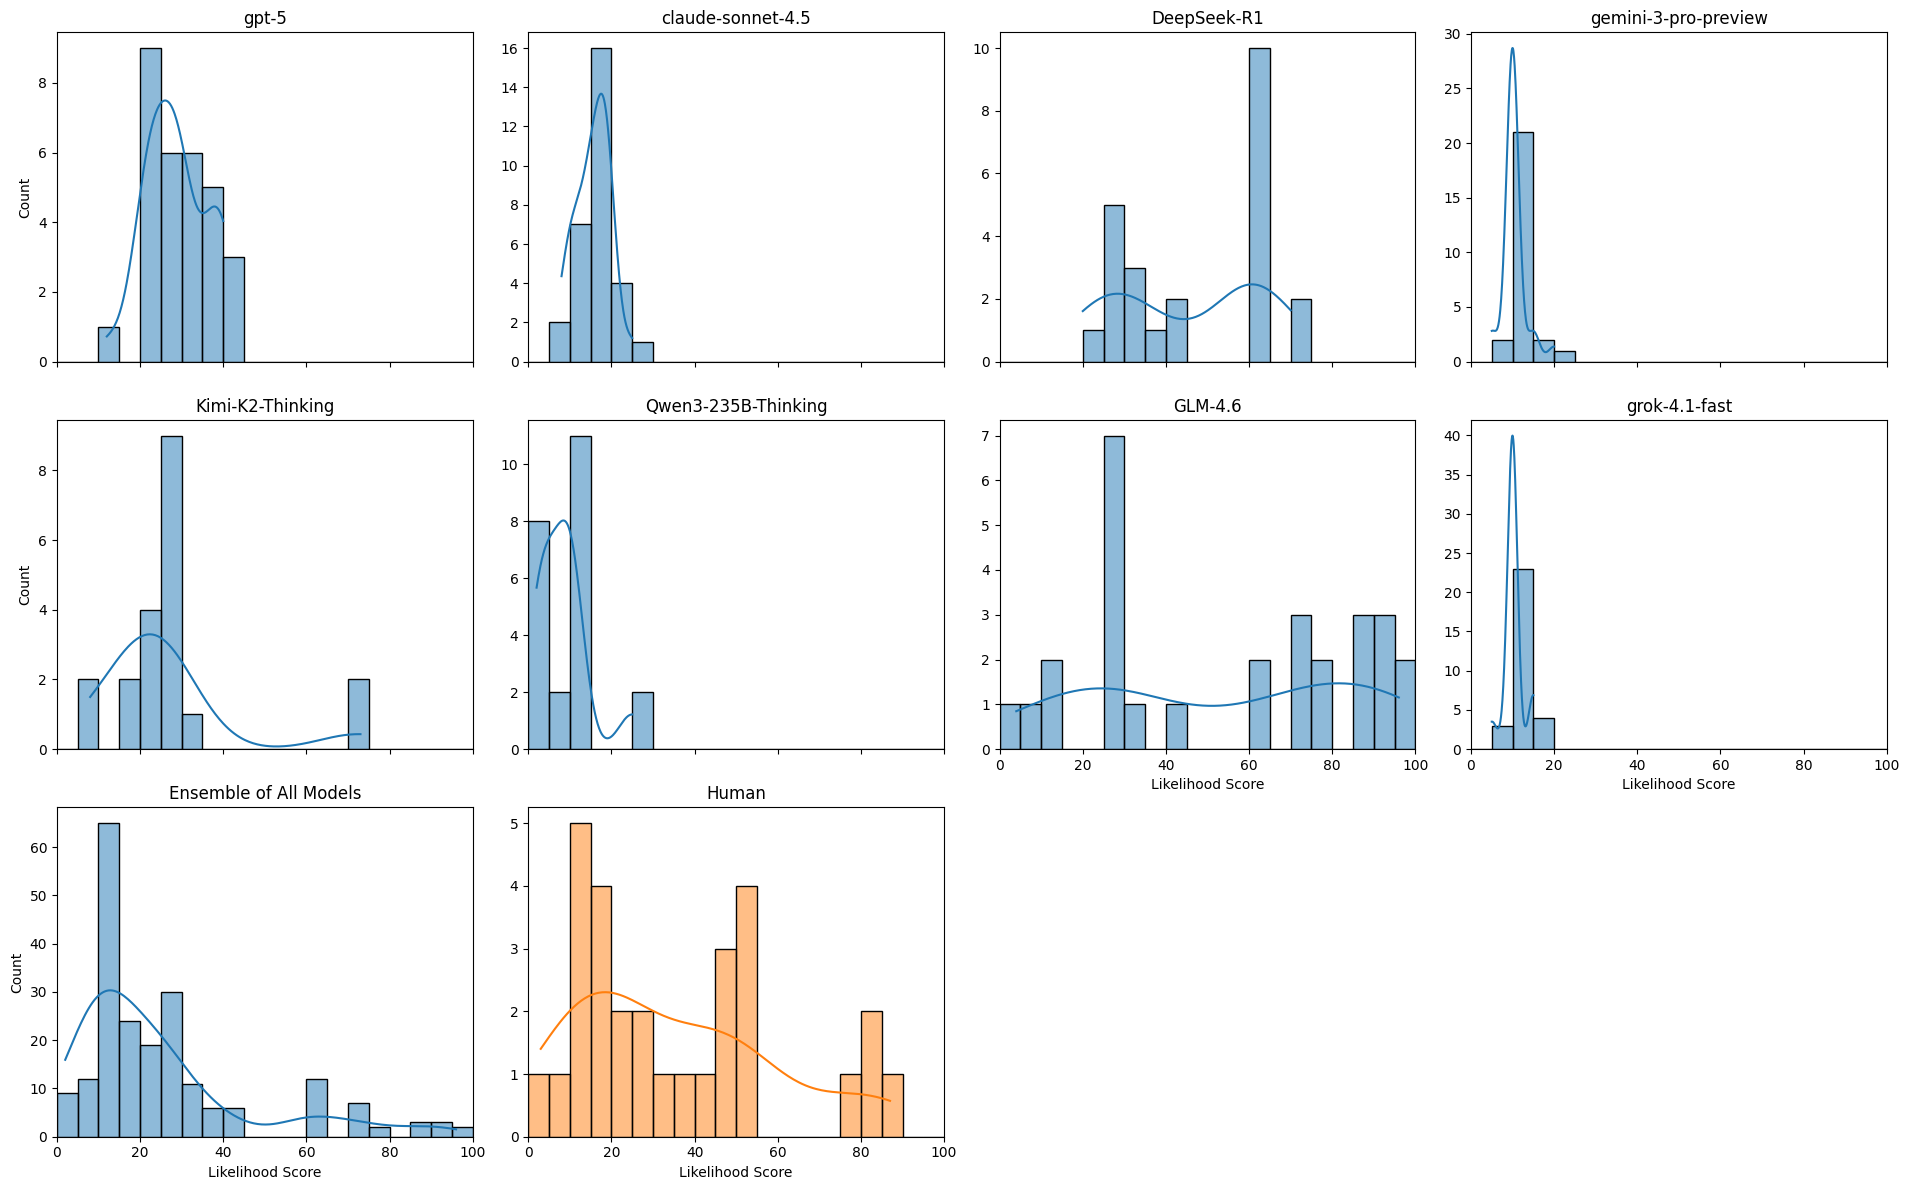

In [204]:
random_sample = np.random.choice(joint_results['UID'].unique(), size=1, replace=False)
random_sample_results = joint_results[joint_results['UID'].isin(random_sample)]

premise = random_sample_results['premise'].unique()[0]
hypothesis = random_sample_results['hypothesis'].unique()[0]
asks_for = random_sample_results['asks-for'].unique()[0]

print(f"Premise: {premise}")
print(f"Hypothesis: {hypothesis}")
print(f"Asks-for: {asks_for}")

# Get unique sources from the sample and separate models from human
all_sources = random_sample_results['source'].unique()
model_sources = [s for s in all_sources if s != 'human']
human_source = 'human' if 'human' in all_sources else None

# Set up grid: 4 columns, rows for models (2 rows) + 1 row for ensemble and human
n_columns = 4
n_model_rows = (len(model_sources) + n_columns - 1) // n_columns  # Ceiling division for models
n_rows = n_model_rows + 1  # Add one row for ensemble and human

fig, axs = plt.subplots(n_rows, n_columns, figsize=(4.8*n_columns, 4*n_rows))

# Flatten axs array for easier indexing
axs = axs.flatten()

# Plot individual models
for i, source in enumerate(model_sources):
    source_data = random_sample_results[random_sample_results['source'] == source]
    sns.histplot(data=source_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[i])
    axs[i].set_xlim(0, 100)
    axs[i].set_title(source)
    # Only show y-axis label on leftmost plots (i.e., i % n_columns == 0)
    if i % n_columns == 0:
        axs[i].set_ylabel('Count')
    else:
        axs[i].set_ylabel('')
    # Show x-axis label only on bottom-most plots in columns 2 and 3
    # (i.e., last row of models AND column >= 2)
    column = i % n_columns
    if i >= len(model_sources) - n_columns and column >= 2:
        axs[i].set_xlabel('Likelihood Score')
    else:
        axs[i].set_xlabel('')
        # Hide x-axis tick labels for plots that don't need them
        axs[i].set_xticklabels([])

# Add ensemble of all models in the last row (column 0)
ensemble_idx = n_model_rows * n_columns
model_ensemble_data = random_sample_results[random_sample_results['source'] != 'human']
sns.histplot(data=model_ensemble_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[ensemble_idx])
axs[ensemble_idx].set_xlim(0, 100)
axs[ensemble_idx].set_title('Ensemble of All Models')
axs[ensemble_idx].set_ylabel('Count')
axs[ensemble_idx].set_xlabel('Likelihood Score')

# Add human results in the last row (column 1, with custom color)
if human_source:
    human_idx = ensemble_idx + 1
    human_data = random_sample_results[random_sample_results['source'] == 'human']
    sns.histplot(data=human_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[human_idx], color='#ff7f0e')
    axs[human_idx].set_xlim(0, 100)
    axs[human_idx].set_title('Human')
    axs[human_idx].set_ylabel('')
    axs[human_idx].set_xlabel('Likelihood Score')

# Hide any unused subplots
for j in range(len(model_sources) + (2 if human_source else 1), n_rows * n_columns):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


## Plot: Humans vs Models Overall Response Distribution (Figure 7)

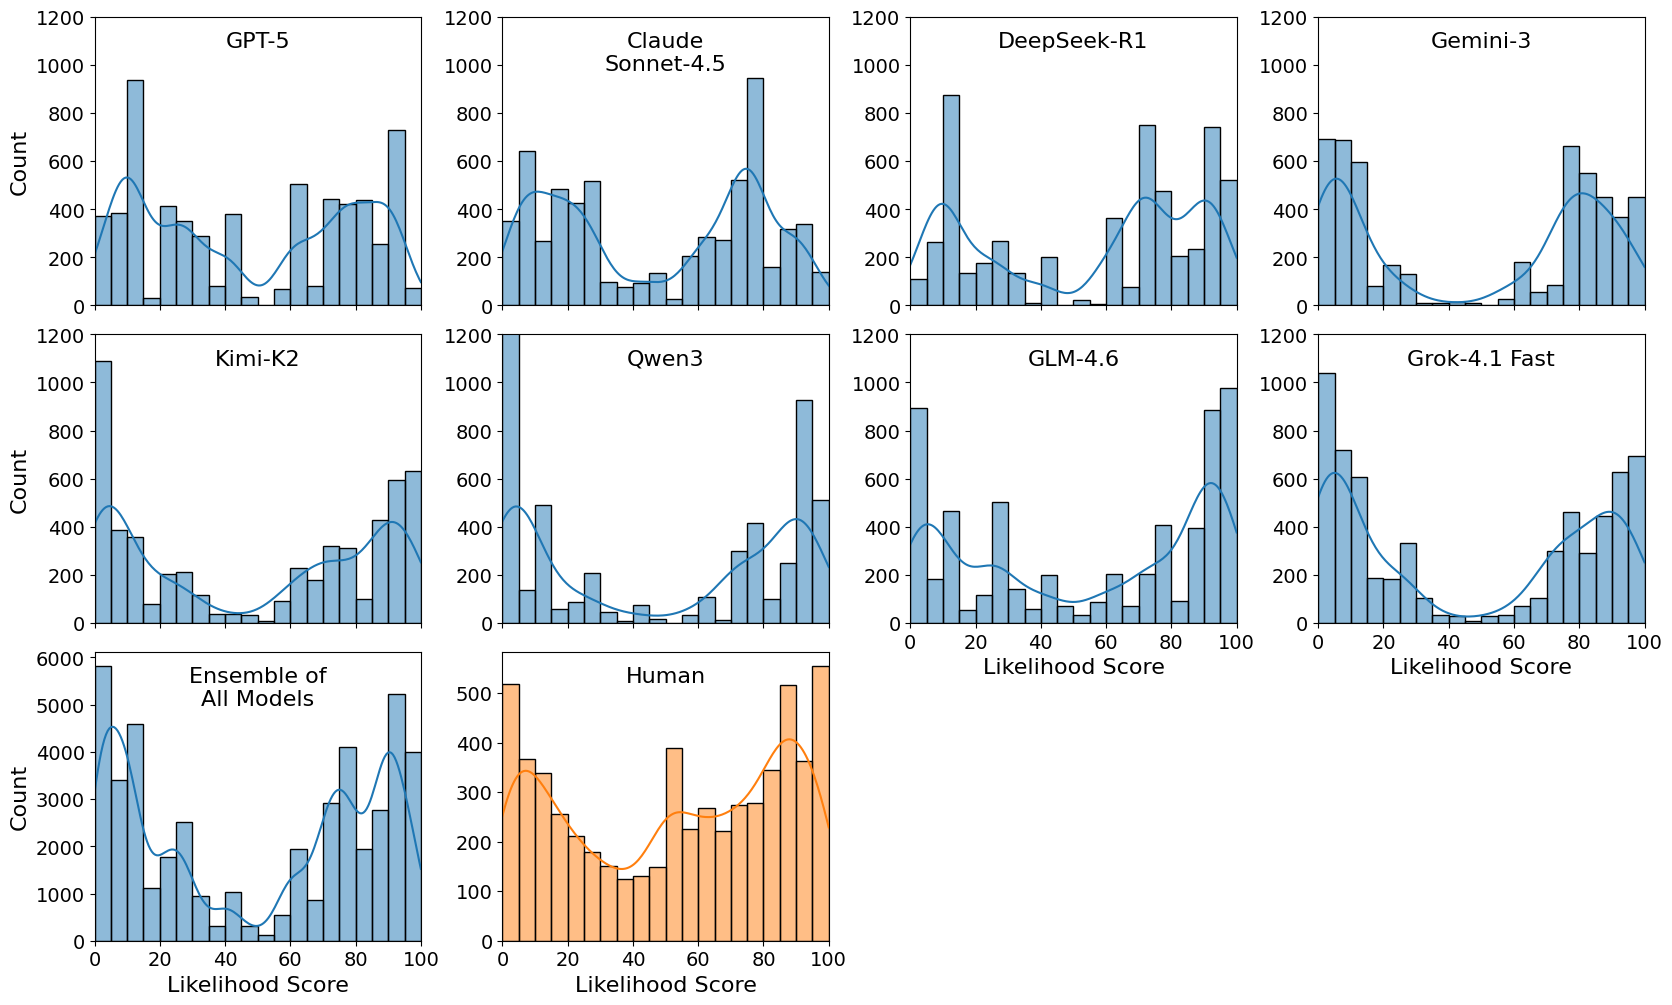

In [205]:
# Model name formatting
model_to_formatted_name = {
    'gpt-5': 'GPT-5', 
    'grok-4.1-fast': 'Grok-4.1 Fast', 
    'claude-sonnet-4.5': 'Claude\nSonnet-4.5', 
    'Qwen3-235B-Thinking': 'Qwen3', 
    'DeepSeek-R1': 'DeepSeek-R1',
    'gemini-3-pro-preview': 'Gemini-3', 
    'Kimi-K2-Thinking': 'Kimi-K2', 
    'GLM-4.6': 'GLM-4.6',
    'human': 'Human'
}

# Get unique sources and separate models from human
all_sources = joint_results['source'].unique()
model_sources = [s for s in all_sources if s != 'human']
human_source = 'human' if 'human' in all_sources else None

# Set up grid: 4 columns, rows for models (2 rows) + 1 row for ensemble and human
n_columns = 4
n_model_rows = (len(model_sources) + n_columns - 1) // n_columns  # Ceiling division for models
n_rows = n_model_rows + 1  # Add one row for ensemble and human

fig, axs = plt.subplots(n_rows, n_columns, figsize=(5*n_columns, 4*n_rows))

# Flatten axs array for easier indexing
axs = axs.flatten()

# Plot individual models
for i, source in enumerate(model_sources):
    source_data = joint_results[joint_results['source'] == source]
    sns.histplot(data=source_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[i])
    axs[i].set_xlim(0, 100)
    axs[i].set_ylim(0,1200)
    # Place title as text inside the plot (top-center)
    formatted_name = model_to_formatted_name.get(source, source)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes, 
                fontsize=16, va='top', ha='center')
    # Only show y-axis label on leftmost plots (i.e., i % n_columns == 0)
    if i % n_columns == 0:
        axs[i].set_ylabel('Count', fontsize=16)
    else:
        axs[i].set_ylabel('')
    # Show x-axis label only on bottom-most plots in columns 2 and 3
    # (i.e., last row of models AND column >= 2)
    column = i % n_columns
    if i >= len(model_sources) - n_columns and column >= 2:
        axs[i].set_xlabel('Likelihood Score', fontsize=16)
    else:
        axs[i].set_xlabel('')
        # Hide x-axis tick labels for plots that don't need them
        axs[i].set_xticklabels([])
    axs[i].tick_params(labelsize=14)

# Add ensemble of all models in the last row (column 0)
ensemble_idx = n_model_rows * n_columns
model_ensemble_data = joint_results[joint_results['source'] != 'human']
sns.histplot(data=model_ensemble_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[ensemble_idx])
axs[ensemble_idx].set_xlim(0, 100)
axs[ensemble_idx].text(0.5, 0.95, 'Ensemble of\nAll Models', transform=axs[ensemble_idx].transAxes,
                       fontsize=16, va='top', ha='center')
axs[ensemble_idx].set_ylabel('Count', fontsize=16)
axs[ensemble_idx].set_xlabel('Likelihood Score', fontsize=16)
axs[ensemble_idx].tick_params(labelsize=14)


# Add human results in the last row (column 1, with custom color)
if human_source:
    human_idx = ensemble_idx + 1
    human_data = joint_results[joint_results['source'] == 'human']
    sns.histplot(data=human_data, x='response', bins=list(range(0,101,5)), kde=True, ax=axs[human_idx], color='#ff7f0e')
    axs[human_idx].set_xlim(0, 100)
    axs[human_idx].text(0.5, 0.95, 'Human', transform=axs[human_idx].transAxes,
                        fontsize=16, va='top', ha='center')
    axs[human_idx].set_ylabel('')
    axs[human_idx].set_xlabel('Likelihood Score', fontsize=16)
    axs[human_idx].tick_params(labelsize=14)

# Hide any unused subplots
for j in range(len(model_sources) + (2 if human_source else 1), n_rows * n_columns):
    axs[j].set_visible(False)

# Adjust spacing between subplots (reduce whitespace)
plt.subplots_adjust(hspace=0.1, wspace=0.25)
plt.savefig("./plots/model_response_distributions_ALL.pdf", dpi=300, bbox_inches='tight')

plt.show()

## Plot: Selected Models' Overall Response Distribution (Figure 3) 

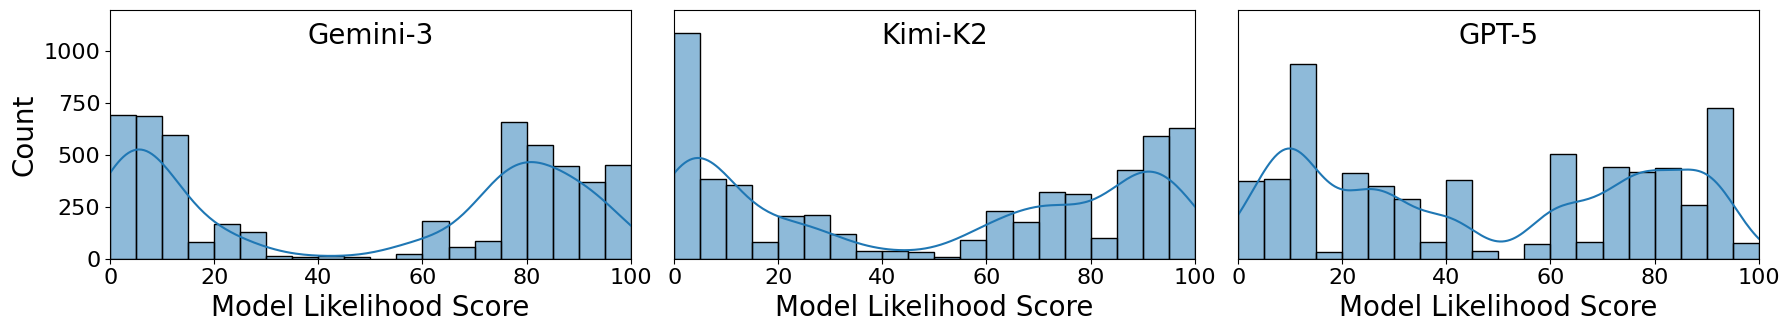

In [206]:
models_selected = ['gemini-3-pro-preview', 'Kimi-K2-Thinking', 'gpt-5']
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3', 'gpt-5': 'GPT-5', 'Kimi-K2-Thinking': 'Kimi-K2'}
fig,axs = plt.subplots(1,len(models_selected),figsize=(6*len(models_selected),3.5))
for i,model in enumerate(models_selected):
    sns.histplot(data=joint_results[joint_results['source']==model], x='response', bins=list(range(0,101,5)), kde=True, ax=axs[i])
    # axs[i].set_title(model_to_formatted_name[model], fontsize=18)
    axs[i].text(0.5, 0.95, model_to_formatted_name[model], 
                transform=axs[i].transAxes, 
                fontsize=20,
                ha='center', 
                va='top',
                )
    axs[i].set_xlabel("Model Likelihood Score", fontsize=20)
    axs[i].tick_params(labelsize=18)
    if i == 0:
        axs[i].set_ylabel("Count", fontsize=20)
    else:
        axs[i].set_ylabel("")
        axs[i].set_yticks([])
    axs[i].set_xlim(0,100)
    axs[i].set_ylim(0,1200)
    axs[i].tick_params(labelsize=16)

plt.tight_layout()
plt.savefig("./plots/model_response_distributions.pdf", dpi=300)
plt.show()


## Plot: Wasserstein Distances from Human Distributions (Figure 10)

In [207]:
def get_wasserstein_distance_from_human(UID, base_df):
    model_dist = base_df[base_df['UID'] == UID]['response']
    if np.isnan(model_dist).all():
        return np.nan
    model_dist = model_dist[~np.isnan(model_dist)]
    human_dist = human_results[human_results['UID'] == UID]['response']
    return stats.wasserstein_distance(model_dist, human_dist)

def get_human_agg_response(UID, measure):
    return human_results[human_results['UID'] == UID][f'{measure}_response'].iloc[0]


for model_result in model_results.values():
    model_result['wasserstein_distance_from_human'] = model_result.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=model_result))
    model_result['human_median_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    model_result['human_mean_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    model_result['human_std_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    model_result['human_diff_entropy_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))

# Important: now we'll also get wasserstein distances from human validation results:
human_validation_results['wasserstein_distance_from_human'] = human_validation_results.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=human_validation_results))
human_validation_results['human_diff_entropy_response'] = human_validation_results['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy')) # Important note: this is the diff entropy of the original human responses, not the human validation results
human_validation_results['human_median_response'] = human_validation_results['UID'].apply(lambda x: get_human_agg_response(x, 'median')) # Important note: this is the median of the original human responses, not the human validation results
median_human_validation_results_wasserstein_distance = human_validation_results['wasserstein_distance_from_human'].median()

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/1417161818.py:96: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ensemble_results = pd.concat(model_results.values()).copy()


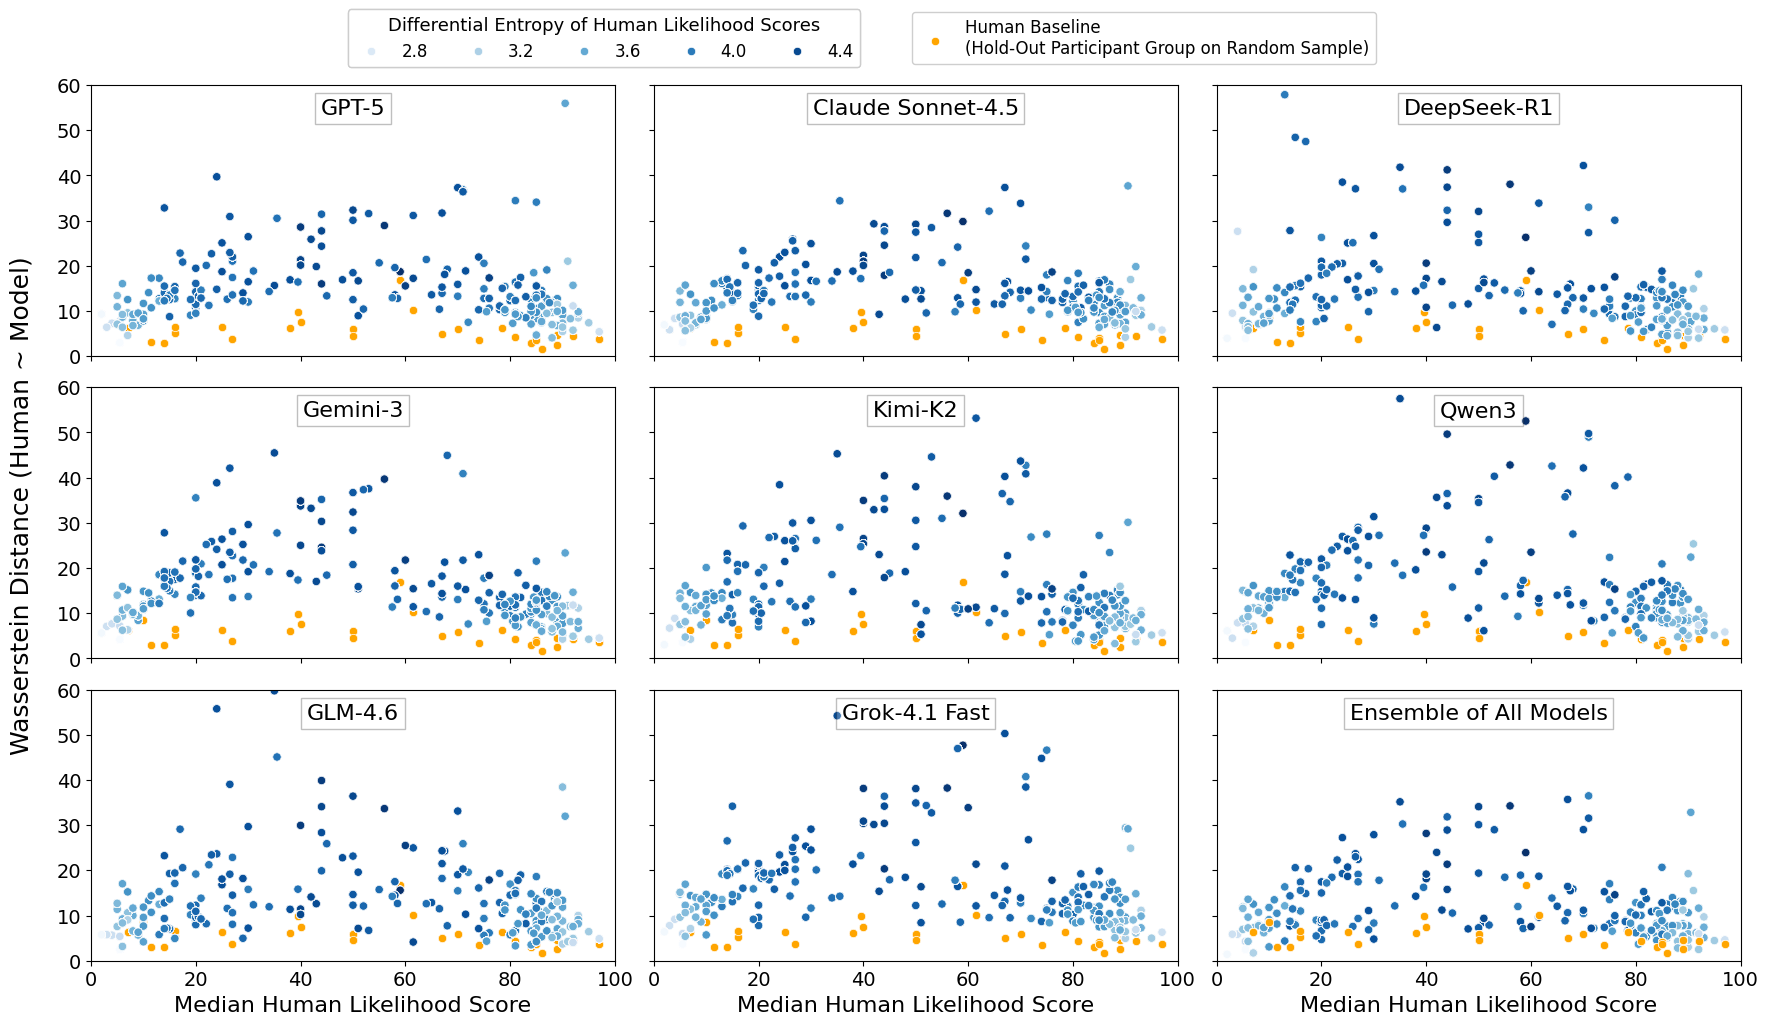

In [208]:
# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns  # Ceiling division; add an extra spot for the ensemble of models

# Model name formatting
model_to_formatted_name = {
    'gpt-5': 'GPT-5', 
    'grok-4.1-fast': 'Grok-4.1 Fast', 
    'claude-sonnet-4.5': 'Claude Sonnet-4.5', 
    'Qwen3-235B-Thinking': 'Qwen3', 
    'DeepSeek-R1': 'DeepSeek-R1',
    'gemini-3-pro-preview': 'Gemini-3', 
    'Kimi-K2-Thinking': 'Kimi-K2', 
    'GLM-4.6': 'GLM-4.6'
}

# Create figure with shared axes
fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 3.5*n_rows), 
                         sharex=True, sharey=True)
measure = 'median'

human_validation_color = 'orange'

# Flatten axs array for easier indexing if it's 2D
if n_rows > 1:
    axs = axs.flatten()
elif n_columns == 1:
    axs = [axs]

# Store handles for shared legends (will collect from first plot)
entropy_handles, entropy_labels = None, None
baseline_handle, baseline_label = None, None

for i, model in enumerate(models):
    # For the first plot, create legends to collect handles
    show_legend = (i == 0)
    
    # Human baseline scatter
    sns.scatterplot(
        data=human_validation_results,
        x='human_median_response',
        y='wasserstein_distance_from_human',
        ax=axs[i],
        color=human_validation_color,
        label='Human Baseline\n(Hold-Out Participant Group on Random Sample)',
        legend=show_legend
    )
    # Model scatter with entropy hue
    sns.scatterplot(
        data=model_results[model],
        x=f'human_{measure}_response',
        y='wasserstein_distance_from_human',
        hue='human_diff_entropy_response',
        palette='Blues',
        ax=axs[i],
        legend=show_legend
    )
    
    # Collect legend handles from first plot, then remove the legend
    if i == 0:
        handles, labels = axs[i].get_legend_handles_labels()
        baseline_label_text = 'Human Baseline\n(Hold-Out Participant Group on Random Sample)'
        baseline_indices = [idx for idx, lab in enumerate(labels) if lab == baseline_label_text]
        if baseline_indices:
            b_idx = baseline_indices[0]
            baseline_handle = [handles[b_idx]]
            baseline_label = [labels[b_idx]]
            entropy_handles = [h for j, h in enumerate(handles) if j != b_idx]
            entropy_labels = [lab for j, lab in enumerate(labels) if j != b_idx]
        else:
            baseline_handle = handles[:1]
            baseline_label = labels[:1]
            entropy_handles = handles[1:]
            entropy_labels = labels[1:]
        # Remove the legend from first plot
        axs[i].get_legend().remove()
    
    # Set labels only for bottom row
    if i >= (n_rows - 1) * n_columns:
        axs[i].set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=16)
    else:
        axs[i].set_xlabel("")
    
    # Add title inside the plot (centered at top)
    formatted_name = model_to_formatted_name.get(model, model)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes, 
                fontsize=16, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.25))
    
    axs[i].tick_params(labelsize=14)
    axs[i].set_xlim(0, 100)
    axs[i].set_ylim(0, 60)
    axs[i].set_ylabel("") # remove y-axis label

# Add ensemble of all models:
# Calculate wasserstein distance for ensemble
ensemble_results = pd.concat(model_results.values()).copy()
ensemble_results['wasserstein_distance_from_human'] = ensemble_results.groupby('UID')['response'].transform(
    lambda s: get_wasserstein_distance_from_human(s.name, base_df=ensemble_results)
)

# Model ensemble scatter with entropy hue
sns.scatterplot(
    data=ensemble_results,
    x=f'human_{measure}_response',
    y='wasserstein_distance_from_human',
    hue='human_diff_entropy_response',
    palette='Blues',
    ax=axs[len(models)],
    legend=False
)

# Human baseline scatter on ensemble panel
sns.scatterplot(
    data=human_validation_results,
    x='human_median_response',
    y='wasserstein_distance_from_human',
    ax=axs[len(models)],
    color=human_validation_color,
    label='Human Baseline\n(Hold-Out Participant Group on Random Sample)',
    legend=False
)

# Set labels for ensemble subplot
axs[len(models)].set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=16)

# Add title inside the ensemble plot
axs[len(models)].text(0.5, 0.95, 'Ensemble of All Models', transform=axs[len(models)].transAxes,
                       fontsize=16, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.25))

axs[len(models)].tick_params(labelsize=14)
axs[len(models)].set_xlim(0, 100)
axs[len(models)].set_ylim(0, 60)

# Hide any unused subplots
for j in range(len(models)+1, n_rows * n_columns):
    axs[j].set_visible(False)

# Add shared y-axis label for entire grid
fig.supylabel("Wasserstein Distance (Human ~ Model)", fontsize=18)

plt.tight_layout()

# Add two shared legends at the top (side-by-side)
if entropy_handles and baseline_handle:
    # Legend 1: Differential Entropy (color scale)
    legend1 = fig.legend(
        entropy_handles,
        entropy_labels,
        title='Differential Entropy of Human Likelihood Scores',
        fontsize=12,
        title_fontsize=13,
        loc='upper center',
        bbox_to_anchor=(0.35, 0.98),
        framealpha=0.95,
        ncol=len(entropy_handles)
    )
    
    # Legend 2: Human Baseline
    legend2 = fig.legend(
        baseline_handle,
        baseline_label,
        fontsize=12,
        loc='upper center',
        bbox_to_anchor=(0.65, 0.9775),
        framealpha=0.95
    )
    
    # Add first legend back to figure (otherwise it gets removed when second is created)
    fig.add_artist(legend1)

plt.subplots_adjust(top=0.90, left=0.065)  # Make room for the legends at the top

plt.savefig("./plots/model_vs_human_wasserstein_distance_all_models.pdf", dpi=300)

plt.show()


## Plot: Wasserstein Distance from Human Distribution for Single Model

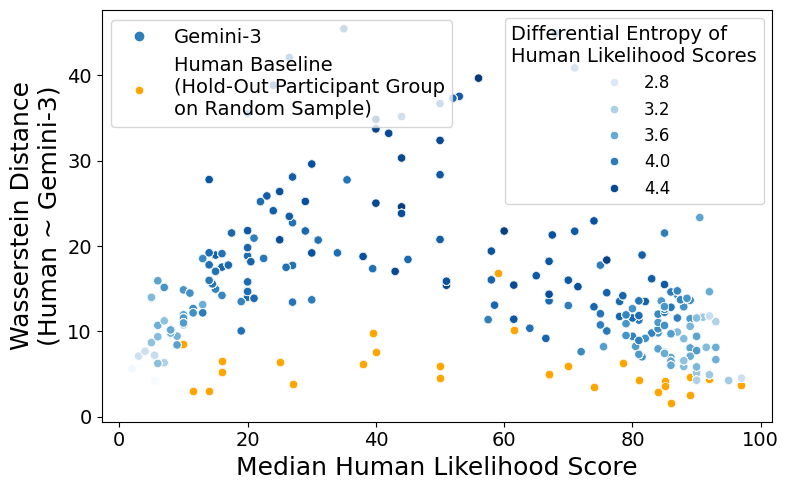

In [209]:
from matplotlib.lines import Line2D

# One model only:
selected_model = 'gemini-3-pro-preview'
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3'}
measure = 'median'
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

human_validation_color = 'orange'

# Human baseline scatter
sns.scatterplot(
    data=human_validation_results,
    x='human_median_response',
    y='wasserstein_distance_from_human',
    ax=axs,
    color=human_validation_color,
    label='Human Baseline\n(Hold-Out Participant Group\non Random Sample)'
)

# Model scatter with Blues hue and default legend (for entropy)
sns.scatterplot(
    data=model_results[selected_model],
    x=f'human_{measure}_response',
    y='wasserstein_distance_from_human',
    hue='human_diff_entropy_response',
    palette='Blues',  # Changed from 'viridis'
    ax=axs
)

axs.set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=18)
axs.set_ylabel(
    f"Wasserstein Distance\n(Human ~ {model_to_formatted_name[selected_model]})",
    fontsize=18
)
axs.tick_params(labelsize=14)

# Grab all handles/labels from the auto legend
handles, labels = axs.get_legend_handles_labels()

# Assume first is the baseline, rest are entropy levels
baseline_handle = handles[0]
baseline_label = labels[0]
entropy_handles = handles[1:]
entropy_labels = labels[1:]

# First legend: differential entropy (colorbar-style)
legend1 = axs.legend(
    entropy_handles,
    entropy_labels,
    title='Differential Entropy of\nHuman Likelihood Scores',
    fontsize=12,
    title_fontsize=14,
    loc='upper right',
    alignment='center'
)
axs.add_artist(legend1)

# Second legend: model vs human baseline (manual handles)
blues_cmap = sns.color_palette('Blues', as_cmap=True)  # Changed from 'viridis'
model_legend_color = blues_cmap(0.7)  # Use 0.7 for a mid-range blue (adjust as needed)

model_handle = Line2D(
    [], [], marker='o', linestyle='',
    color=model_legend_color,
    label='Model Responses'
)

axs.legend(
    [model_handle, baseline_handle],
    [model_to_formatted_name[selected_model], baseline_label],
    fontsize=14,
    loc='upper left',
    framealpha=0.8
)

plt.tight_layout()
plt.savefig(f"./plots/model_vs_human_wasserstein_distance_{selected_model}.pdf", dpi=300)
plt.show()

## Plot: Does Ensembling Lead to Better Model-Human Distributional Alignment? (Figure 5)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/350023140.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ensemble_results = pd.concat(model_results.values())
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/350023140.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_joint_model_results = pd.concat(model_results.values()).copy()


['GPT-5' 'Claude\nSonnet-4.5' 'DeepSeek-R1' 'Gemini-3' 'Kimi-K2' 'Qwen3'
 'GLM-4.6' 'Grok-4.1 Fast' 'Ensemble of\nAll Models']


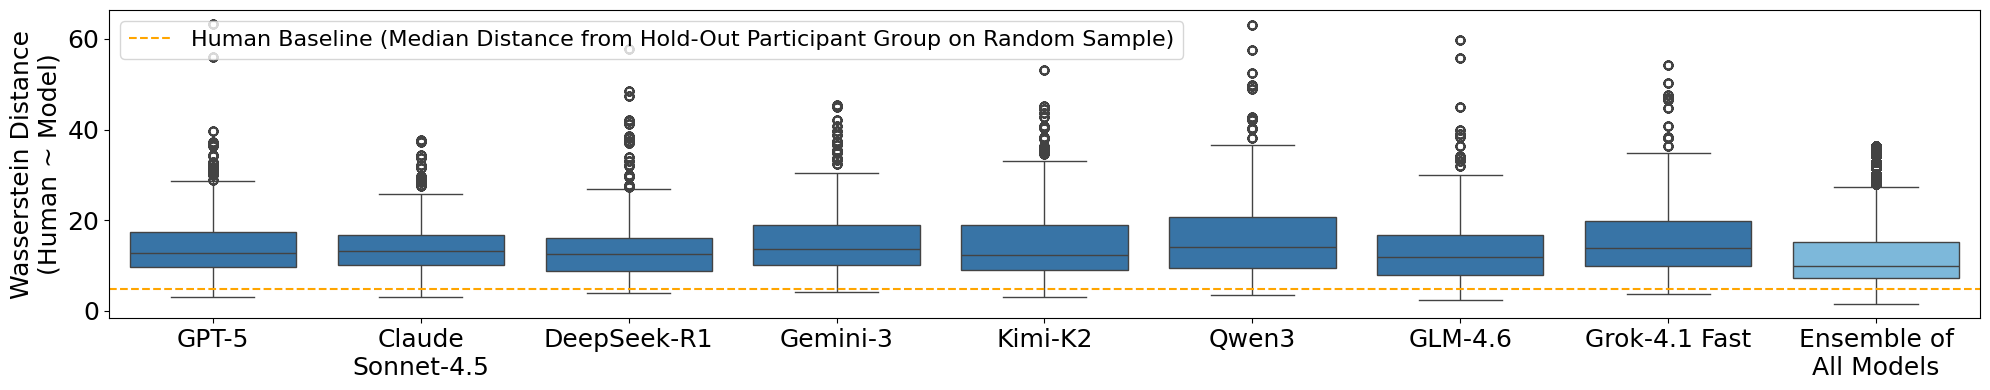

In [210]:
model_to_formatted_name = {'gpt-5': 'GPT-5', 
                                'grok-4.1-fast': 'Grok-4.1 Fast', 
                                'claude-sonnet-4.5': 'Claude\nSonnet-4.5', 
                                'Qwen3-235B-Thinking': 'Qwen3', 
                                'DeepSeek-R1': 'DeepSeek-R1',
                                'gemini-3-pro-preview': 'Gemini-3', 
                                'Kimi-K2-Thinking': 'Kimi-K2', 
                                'GLM-4.6': 'GLM-4.6',
                                'Ensemble of\nAll Models': 'Ensemble of\nAll Models'
                                }

fig,axs = plt.subplots(1,1,figsize=(20,4))
ensemble_results = pd.concat(model_results.values())
ensemble_results['wasserstein_distance_from_human'] = ensemble_results.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=ensemble_results))
ensemble_results['source'] = 'Ensemble of\nAll Models'
temp_joint_model_results = pd.concat(model_results.values()).copy()
temp_joint_model_results = pd.concat([temp_joint_model_results, ensemble_results]).reset_index(drop=True)
temp_joint_model_results['formatted_source'] = temp_joint_model_results['source'].map(model_to_formatted_name)

sns.boxplot(data=temp_joint_model_results, x='formatted_source', y='wasserstein_distance_from_human', ax=axs, color='#2676b8')
axs.set_xlabel('')
axs.set_ylabel('Wasserstein Distance\n(Human ~ Model)', fontsize=18)
axs.tick_params(labelsize=18)

sources = temp_joint_model_results['formatted_source'].unique()
print(sources)
ensemble_idx = list(sources).index('Ensemble of\nAll Models')
axs.patches[ensemble_idx].set_facecolor('#7db8da')  # or any color you want

# Now overlay the median human wasserstein distance baseline:
human_baseline_line = axs.axhline(y=median_human_validation_results_wasserstein_distance, color='orange', linestyle='--', label='Human Baseline\n(Hold-Out Participant Group\non Random Sample)')
axs.legend([human_baseline_line], ['Human Baseline (Median Distance from Hold-Out Participant Group on Random Sample)'], fontsize=16, loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.savefig("./plots/ensemble_wasserstein_distance_boxplot.pdf", dpi=300)
plt.show()


## Plot: Differential Entropy from Models vs Humans (Figure 12)

In [211]:
def get_human_agg_response(UID, measure):
    return human_results[human_results['UID'] == UID][f'{measure}_response'].iloc[0]


for model_result in model_results.values():
    model_result['wasserstein_distance_from_human'] = model_result.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=model_result))
    model_result['human_median_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    model_result['human_mean_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    model_result['human_std_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    model_result['human_diff_entropy_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))


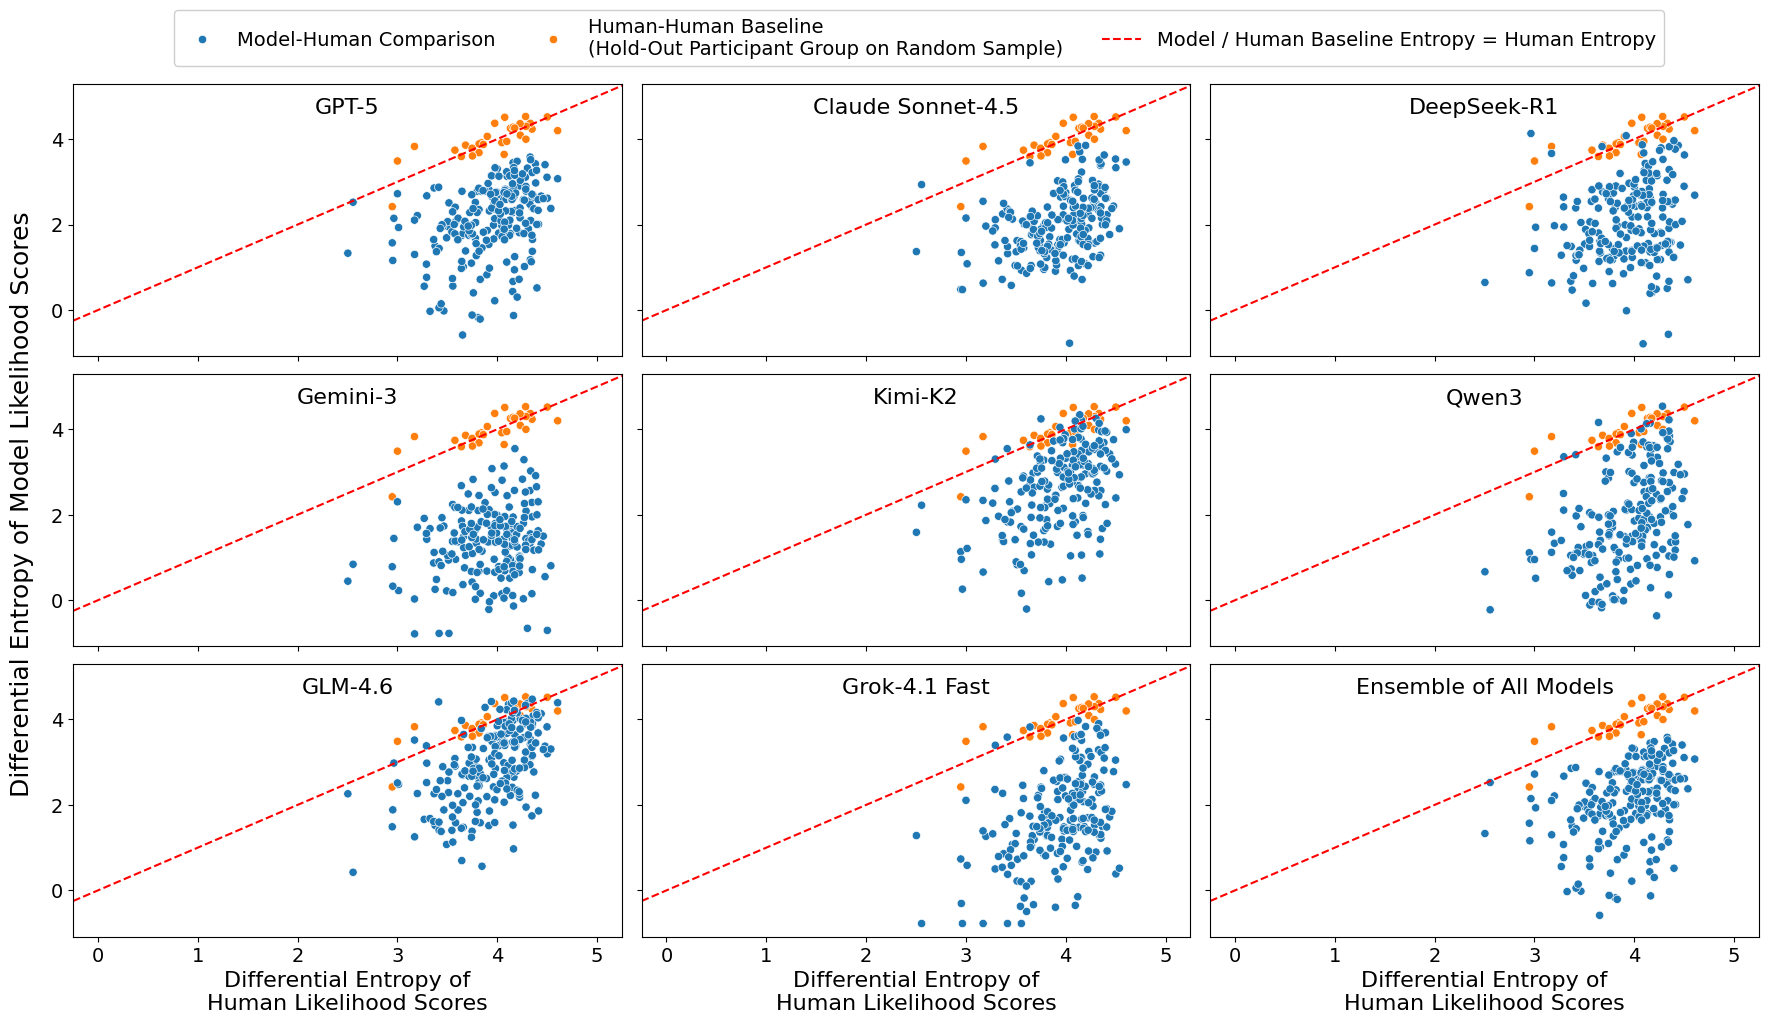

In [212]:
from matplotlib.lines import Line2D

model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
                               'claude-sonnet-4.5': 'Claude Sonnet-4.5', 
                               'Qwen3-235B-Thinking': 'Qwen3', 
                               'DeepSeek-R1': 'DeepSeek-R1',
                               'gemini-3-pro-preview': 'Gemini-3', 
                               'Kimi-K2-Thinking': 'Kimi-K2', 
                               'GLM-4.6': 'GLM-4.6',
                               'Ensemble of All Models': 'Ensemble of All Models'
                               }

# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns  # Ceiling division; add an extra spot for the ensemble of models

# Create figure with shared axes
fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 3.5*n_rows),
                         sharex=True, sharey=True)
measure = 'diff_entropy'

# Flatten axs array for easier indexing if it's 2D
if n_rows > 1:
    axs = axs.flatten()
elif n_columns == 1:
    axs = [axs]

entropy_grouped = joint_results.groupby(['UID', 'source']).agg({'diff_entropy_response': 'first'}).reset_index()
entropy_grouped_for_plotting = entropy_grouped.pivot(index='UID', columns='source', values='diff_entropy_response').reset_index(drop=True)

human_validation_color = 'orange'
human_validation_label = 'Human-Human Baseline\n(Hold-Out Participant Group on Random Sample)'
human_validation_grouped = human_validation_results.groupby(['UID']).agg({'human_diff_entropy_response': 'first', 'diff_entropy_response': 'first'}).reset_index()
human_validation_grouped['type'] = human_validation_label

# Store handles for shared legends
model_handles, baseline_handles, line_handle = None, None, None

for i, model in enumerate(models):
    show_legend = (i == 0)
    
    hue_order = [model_to_formatted_name[model], human_validation_label]
    entropy_grouped_for_plotting['type'] = model_to_formatted_name[model]
    entropy_grouped_for_plotting['human_diff_entropy_response'] = entropy_grouped_for_plotting['human']
    entropy_grouped_for_plotting['diff_entropy_response'] = entropy_grouped_for_plotting[model]
    temp_grouped = pd.concat([human_validation_grouped, entropy_grouped_for_plotting]).reset_index(drop=True)
    
    sns.scatterplot(data=temp_grouped, x='human_diff_entropy_response', y='diff_entropy_response', 
                    ax=axs[i], hue='type', hue_order=hue_order, legend=show_legend)
    axs[i].axline(xy1=(0, 0), xy2=(5, 5), color='red', linestyle='--')
    
    # Collect legend handles from first plot
    if i == 0:
        handles, labels = axs[i].get_legend_handles_labels()
        # Create the line handle for equality line
        line_handle = Line2D([0], [0], color='red', linestyle='--', label='Model Entropy = Human Entropy')
        # Store model and baseline handles
        model_handles = handles[:1]  # First is model
        baseline_handles = handles[1:]  # Rest is baseline
        # Remove legend from first plot
        axs[i].get_legend().remove()
    
    # Set labels only for bottom row
    if i >= (n_rows - 1) * n_columns:
        axs[i].set_xlabel("Differential Entropy of\nHuman Likelihood Scores", fontsize=16)
    else:
        axs[i].set_xlabel("")
    
    # Remove y-axis label
    axs[i].set_ylabel("")
    
    # Add title inside the plot
    formatted_name = model_to_formatted_name.get(model, model)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes,
                fontsize=16, ha='center', va='top')
    
    axs[i].tick_params(labelsize=14)

# Add ensemble of all models:
ensemble_label = 'Ensemble of All Models'
ensemble_entropy = joint_model_results.groupby(['UID']).agg({'diff_entropy_response': 'first'}).reset_index()
ensemble_entropy.rename(columns={'diff_entropy_response': 'ensemble'}, inplace=True)

# Merge human and ensemble entropies
entropy_grouped_for_plotting_ensemble = pd.merge(
    entropy_grouped_for_plotting[['human']],
    ensemble_entropy.set_index('UID'),
    left_index=True,
    right_index=True
)

entropy_grouped_for_plotting_ensemble['type'] = ensemble_label
entropy_grouped_for_plotting_ensemble['human_diff_entropy_response'] = entropy_grouped_for_plotting_ensemble['human']
entropy_grouped_for_plotting_ensemble['diff_entropy_response'] = entropy_grouped_for_plotting_ensemble['ensemble']

# Overlay human validation on ensemble plot as well
temp_grouped_ensemble = pd.concat([human_validation_grouped, entropy_grouped_for_plotting_ensemble]).reset_index(drop=True)

hue_order_ensemble = [ensemble_label, human_validation_label]

sns.scatterplot(
    data=temp_grouped_ensemble,
    x='human_diff_entropy_response',
    y='diff_entropy_response',
    ax=axs[len(models)],
    hue='type',
    hue_order=hue_order_ensemble,
    legend=False
)
axs[len(models)].axline(xy1=(0, 0), xy2=(5, 5), color='red', linestyle='--')

# Set labels for ensemble subplot
axs[len(models)].set_xlabel("Differential Entropy of\nHuman Likelihood Scores", fontsize=16)

# Remove y-axis label
axs[len(models)].set_ylabel("")

# Add title inside the ensemble plot
axs[len(models)].text(0.5, 0.95, 'Ensemble of All Models', transform=axs[len(models)].transAxes,
                       fontsize=16, ha='center', va='top')

axs[len(models)].tick_params(labelsize=14)

# Hide any unused subplots
for j in range(len(models)+1, n_rows * n_columns):
    axs[j].set_visible(False)

# Add shared y-axis label for entire grid
fig.supylabel("Differential Entropy of Model Likelihood Scores", fontsize=18)

plt.tight_layout()

# Add shared legend at the top (all items combined)
if model_handles and baseline_handles and line_handle:
    # Combine all handles and labels into one legend
    all_handles = model_handles + baseline_handles + [line_handle]
    all_labels = ['Model-Human Comparison', human_validation_label, 'Model / Human Baseline Entropy = Human Entropy']
    
    fig.legend(
        all_handles,
        all_labels,
        fontsize=14,
        loc='upper center',
        bbox_to_anchor=(0.525, 0.98),
        framealpha=0.95,
        ncol=3
    )

plt.subplots_adjust(top=0.90, left=0.055)  # Make room for the legends at the top

plt.savefig(f"./plots/model_vs_human_entropy_all_models.pdf", dpi=300)

plt.show()

## Plot: Entropy from Models vs Humans (One Model Only)

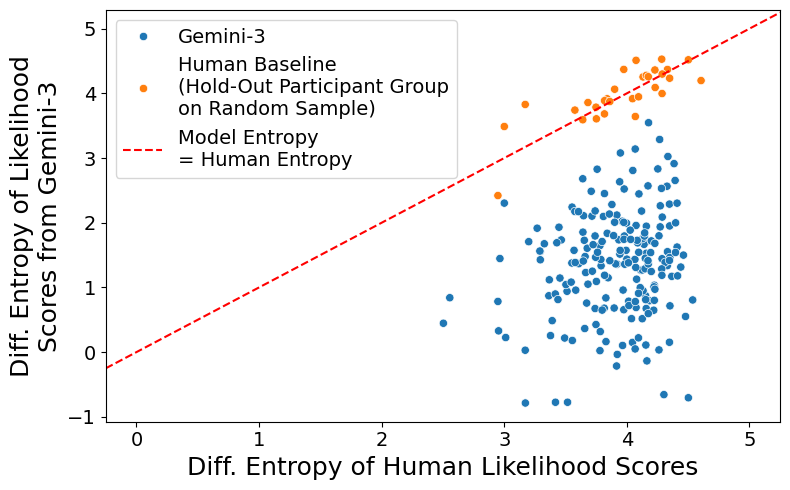

In [213]:
# Now, only one model:
selected_model = 'gemini-3-pro-preview'
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3'}
fig, axs = plt.subplots(1, 1, figsize=(8, 5))

measure = 'diff_entropy'

entropy_grouped = joint_results.groupby(['UID', 'source']).agg({'diff_entropy_response': 'first'}).reset_index()
entropy_grouped_for_plotting = entropy_grouped.pivot(index='UID', columns='source', values='diff_entropy_response').reset_index(drop=True)
entropy_grouped_for_plotting_selected_model = entropy_grouped_for_plotting[['human', selected_model]].copy()

# Labels
human_validation_label = 'Human Baseline\n(Hold-Out Participant Group\non Random Sample)'
model_label = model_to_formatted_name[selected_model]

# Human validation data
human_validation_grouped = human_validation_results.groupby(['UID']).agg(
    {'human_diff_entropy_response': 'first', 'diff_entropy_response': 'first'}
).reset_index()
human_validation_grouped['type'] = human_validation_label

# Full-sample model vs human data in same schema
entropy_grouped_for_plotting_selected_model['human_diff_entropy_response'] = entropy_grouped_for_plotting_selected_model['human']
entropy_grouped_for_plotting_selected_model['diff_entropy_response'] = entropy_grouped_for_plotting_selected_model[selected_model]
entropy_grouped_for_plotting_selected_model['type'] = model_label

temp_grouped = pd.concat(
    [
        human_validation_grouped,
        entropy_grouped_for_plotting_selected_model[
            ['human_diff_entropy_response', 'diff_entropy_response', 'type']
        ]
    ],
    ignore_index=True
)

sns.scatterplot(
    data=temp_grouped,
    x='human_diff_entropy_response',
    y='diff_entropy_response',
    hue='type',
    hue_order=[model_label, human_validation_label],
    ax=axs
)

y_equals_x_line = axs.axline(xy1=(0, 0), xy2=(5, 5), color='red', linestyle='--')
axs.set_xlabel("Diff. Entropy of Human Likelihood Scores", fontsize=18)
axs.set_ylabel(f"Diff. Entropy of Likelihood\nScores from {model_label}", fontsize=18)
axs.tick_params(labelsize=14)

# Combine point legend with line legend
handles, labels = axs.get_legend_handles_labels()
handles.append(y_equals_x_line)
labels.append('Model Entropy\n= Human Entropy')
axs.legend(handles, labels, fontsize=14, loc='upper left')

plt.tight_layout()
plt.savefig(f"./plots/model_vs_human_entropy_{selected_model}.pdf", dpi=300)
plt.show()

## Plot: Model vs Human Median Responses (Figure 11)

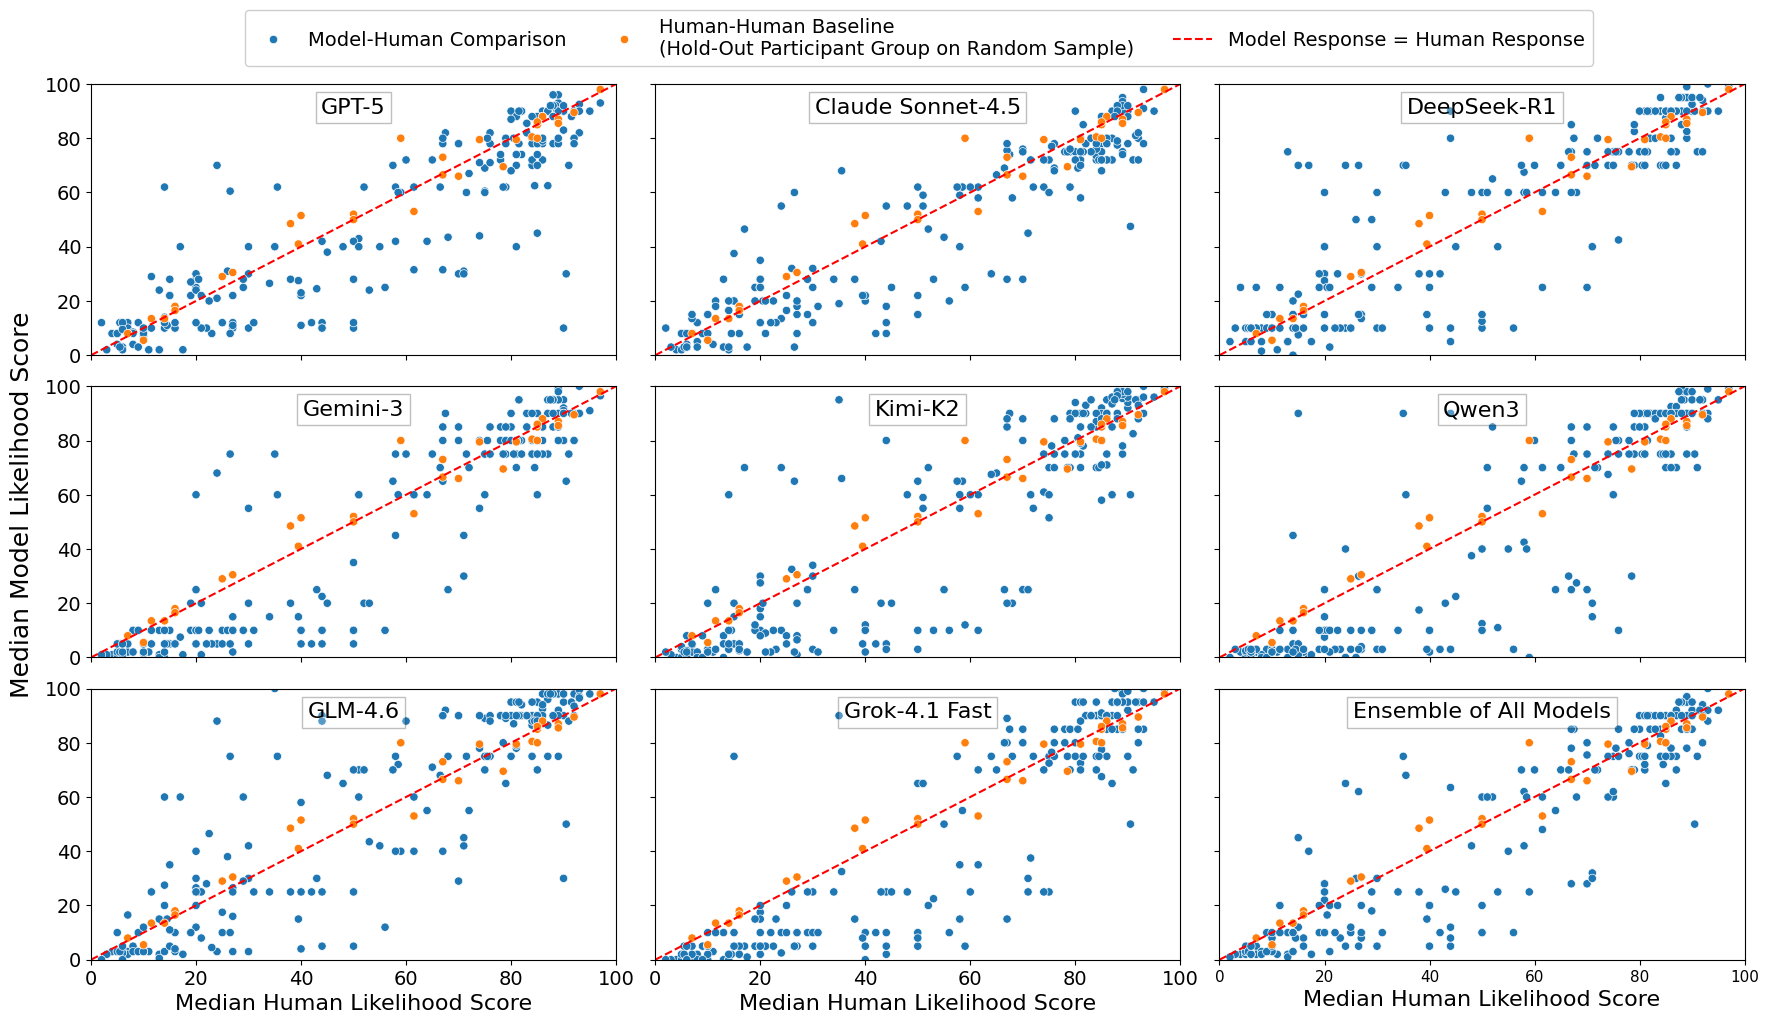

In [214]:
model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
                               'claude-sonnet-4.5': 'Claude Sonnet-4.5', 
                               'Qwen3-235B-Thinking': 'Qwen3', 
                               'DeepSeek-R1': 'DeepSeek-R1',
                               'gemini-3-pro-preview': 'Gemini-3', 
                               'Kimi-K2-Thinking': 'Kimi-K2', 
                               'GLM-4.6': 'GLM-4.6',
                               'Ensemble of All Models': 'Ensemble of All Models'
                               }

measure = 'median'
agg_grouped = joint_results.groupby(['UID', 'source']).agg({f'{measure}_response': 'first'}).reset_index()
agg_grouped_for_plotting = agg_grouped.pivot(index='UID', columns='source', values=f'{measure}_response').reset_index(drop=True)

# Human baseline (validation) medians
human_validation_color = 'orange'
human_validation_grouped = human_validation_results.groupby(['UID']).agg({
    'human_median_response': 'first',
    'response': 'median'
}).reset_index()
baseline_label = 'Human-Human Baseline\n(Hold-Out Participant Group on Random Sample)'
human_validation_grouped['type'] = baseline_label

# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns  # Ceiling division; add an extra spot for the ensemble of models

# Create figure with shared axes
fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 3.5*n_rows), 
                         sharex=True, sharey=True)

# Flatten axs array for easier indexing if it's 2D
if n_rows > 1:
    axs = axs.flatten()
elif n_columns == 1:
    axs = [axs]

# Store handles for shared legend
model_handles, baseline_handles, line_handle = None, None, None

for i, model in enumerate(models):
    show_legend = (i == 0)
    model_label = model_to_formatted_name.get(model, model)

    # Build model vs human data in the same schema as the human baseline
    df_model = agg_grouped_for_plotting[['human', model]].copy()
    df_model['human_median_response'] = df_model['human']
    df_model['response'] = df_model[model]
    df_model['type'] = model_label

    temp_grouped = pd.concat(
        [
            df_model[['human_median_response', 'response', 'type']],
            human_validation_grouped[['human_median_response', 'response', 'type']],
        ],
        ignore_index=True,
    )

    sns.scatterplot(
        data=temp_grouped,
        x='human_median_response',
        y='response',
        hue='type',
        hue_order=[model_label, baseline_label],
        ax=axs[i],
        legend=show_legend
    )

    # y = x reference line
    y_equals_x_line = axs[i].axline(
        xy1=(0, 0),
        xy2=(100, 100),
        color='red',
        linestyle='--'
    )

    # Collect legend handles from first plot
    if i == 0:
        from matplotlib.lines import Line2D
        handles, labels = axs[i].get_legend_handles_labels()
        # Create line handle for equality line
        line_handle = Line2D([0], [0], color='red', linestyle='--', label='Model Response = Human Response')
        # Store model and baseline handles
        model_handles = handles[:1]  # First is model
        baseline_handles = handles[1:]  # Rest is baseline
        # Remove legend from first plot
        axs[i].get_legend().remove()
    
    # Set labels only for bottom row
    if i >= (n_rows - 1) * n_columns:
        axs[i].set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=16)
    else:
        axs[i].set_xlabel("")
    
    # Remove y-axis label
    axs[i].set_ylabel("")
    
    # Add title inside the plot
    axs[i].text(0.5, 0.95, model_label, transform=axs[i].transAxes,
                fontsize=16, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.25))
    
    axs[i].tick_params(labelsize=14)
    axs[i].set_xlim(0, 100)
    axs[i].set_ylim(0, 100)

# Add ensemble of all models
ensemble_label = 'Ensemble of All Models'
ensemble_medians = joint_model_results.groupby(['UID']).agg({'response': 'median'}).reset_index()
ensemble_medians.rename(columns={'response': 'ensemble'}, inplace=True)

# Merge human and ensemble medians
agg_grouped_for_plotting_ensemble = pd.merge(
    agg_grouped_for_plotting[['human']],
    ensemble_medians.set_index('UID'),
    left_index=True,
    right_index=True
)

agg_grouped_for_plotting_ensemble['human_median_response'] = agg_grouped_for_plotting_ensemble['human']
agg_grouped_for_plotting_ensemble['response'] = agg_grouped_for_plotting_ensemble['ensemble']
agg_grouped_for_plotting_ensemble['type'] = ensemble_label

temp_grouped_ensemble = pd.concat(
    [
        agg_grouped_for_plotting_ensemble[['human_median_response', 'response', 'type']],
        human_validation_grouped[['human_median_response', 'response', 'type']],
    ],
    ignore_index=True,
)

sns.scatterplot(
    data=temp_grouped_ensemble,
    x='human_median_response',
    y='response',
    hue='type',
    hue_order=[ensemble_label, baseline_label],
    ax=axs[len(models)],
    legend=False
)

y_equals_x_line = axs[len(models)].axline(
    xy1=(0, 0),
    xy2=(100, 100),
    color='red',
    linestyle='--'
)

# Set labels for ensemble subplot
axs[len(models)].set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=16)

# Remove y-axis label
axs[len(models)].set_ylabel("")

# Add title inside the ensemble plot
axs[len(models)].text(0.5, 0.95, ensemble_label, transform=axs[len(models)].transAxes,
                       fontsize=16, ha='center', va='top', bbox=dict(facecolor='white', alpha=0.25))

axs[len(models)].tick_params(labelsize=11)
axs[len(models)].set_xlim(0, 100)
axs[len(models)].set_ylim(0, 100)

# Hide any unused subplots
for j in range(len(models) + 1, n_rows * n_columns):
    axs[j].set_visible(False)

fig.supylabel(f"{measure.capitalize()} Model Likelihood Score", fontsize=18)

plt.tight_layout()

# Add shared legend at the top (all items combined)
if model_handles and baseline_handles and line_handle:
    # Combine all handles and labels into one legend
    all_handles = model_handles + baseline_handles + [line_handle]
    all_labels = ['Model-Human Comparison', baseline_label, 'Model Response = Human Response']
    
    fig.legend(
        all_handles,
        all_labels,
        fontsize=14,
        loc='upper center',
        bbox_to_anchor=(0.525, 0.98),
        framealpha=0.95,
        ncol=3
    )

plt.subplots_adjust(top=0.90, left=0.065)  # Make room for the legend at the top

plt.savefig(f"./plots/model_vs_human_median_responses_all_models.pdf", dpi=300)
plt.show()

## Plot: Model vs Human Median Responses (One Model Only)

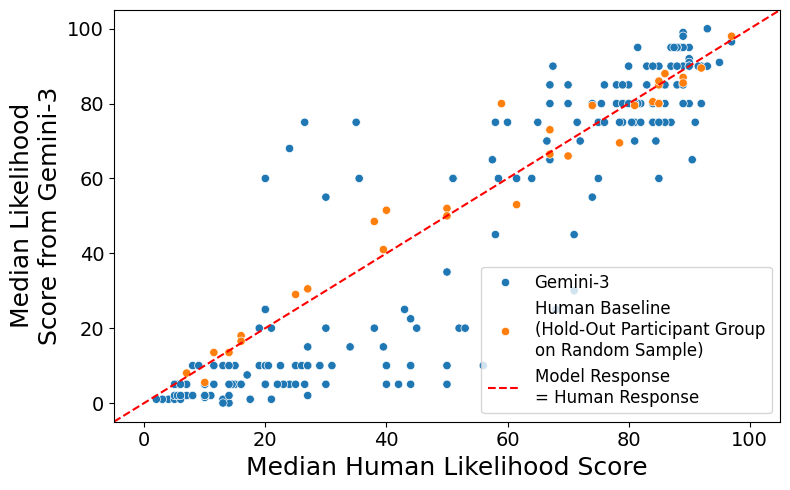

In [215]:
measure = 'median'

agg_grouped = joint_results.groupby(['UID', 'source']).agg({f'{measure}_response': 'first'}).reset_index()
agg_grouped_for_plotting = agg_grouped.pivot(index='UID', columns='source', values=f'{measure}_response').reset_index(drop=True)

selected_model = 'gemini-3-pro-preview'
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3'}
model_label = model_to_formatted_name[selected_model]

agg_grouped_for_plotting_selected_model = agg_grouped_for_plotting[['human', selected_model]].copy()

fig, axs = plt.subplots(1, 1, figsize=(8, 5))

human_validation_color = 'orange'
baseline_label = 'Human Baseline\n(Hold-Out Participant Group\non Random Sample)'

# Human validation medians
human_validation_grouped = human_validation_results.groupby(['UID']).agg(
    {'human_median_response': 'first', 'response': 'median'}
).reset_index()
human_validation_grouped['type'] = baseline_label

# Model vs human medians in same schema
df_model = agg_grouped_for_plotting_selected_model.copy()
df_model['human_median_response'] = df_model['human']
df_model['response'] = df_model[selected_model]
df_model['type'] = model_label

# Combine model + human-baseline, encoded by type
temp_grouped = pd.concat(
    [
        df_model[['human_median_response', 'response', 'type']],
        human_validation_grouped[['human_median_response', 'response', 'type']]
    ],
    ignore_index=True
)

sns.scatterplot(
    data=temp_grouped,
    x='human_median_response',
    y='response',
    hue='type',
    hue_order=[model_label, baseline_label],
    ax=axs,
)

# y = x reference line
y_equals_x_line = axs.axline(
    xy1=(0, 0),
    xy2=(100, 100),
    color='red',
    linestyle='--'
)

axs.set_xlabel("Median Human Likelihood Score", fontsize=18)
axs.set_ylabel(f"Median Likelihood\nScore from {model_label}", fontsize=18)
axs.tick_params(labelsize=14)

# Combine hue legend with equality-line legend
handles, labels = axs.get_legend_handles_labels()
handles.append(y_equals_x_line)
labels.append('Model Response\n= Human Response')
axs.legend(handles, labels, fontsize=12, loc='lower right', framealpha=0.8)

# axs.set_title(model_label, fontsize=16)
plt.tight_layout()

plt.savefig(f"./plots/model_vs_human_median_responses_{selected_model}.pdf", dpi=300)
plt.show()

## Statistical Tests (Table 5) & Plot: Reasoning Chain Length vs Human Response Time 

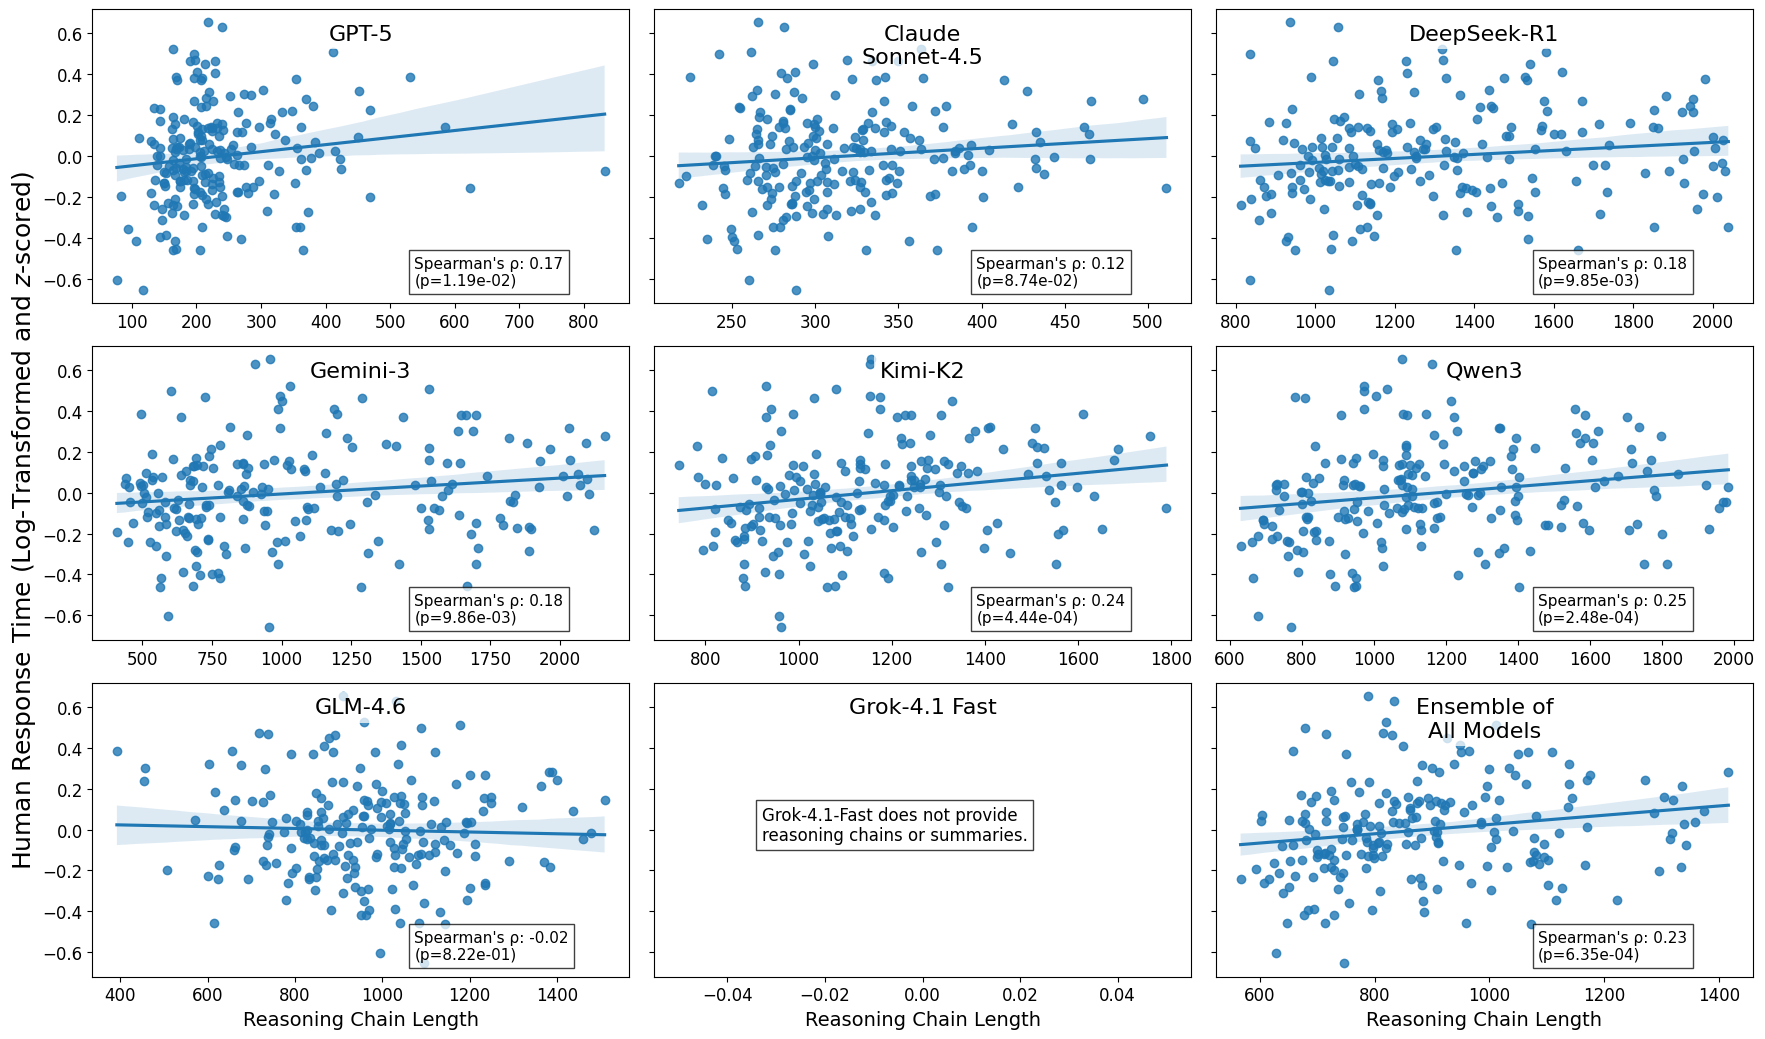

In [216]:
rt_grouped = human_results.groupby(['UID']).agg({'response': 'mean', 'marginal_time': 'mean', 'marginal_time_zscored': 'mean', 'marginal_time_log': 'mean', 'marginal_time_log_zscored': 'mean'}).reset_index()
rt_grouped.rename(columns={'response': 'mean_human_response', 'marginal_time': 'mean_marginal_time', 'marginal_time_zscored': 'mean_marginal_time_zscored', 'marginal_time_log': 'mean_marginal_time_log', 'marginal_time_log_zscored': 'mean_marginal_time_log_zscored'}, inplace=True)
reasoning_grouped = joint_results[joint_results['source'] != 'human'].groupby(['UID', 'source']).agg({'reasoning_token_count': 'mean', 'mean_response': 'first', 'diff_entropy_response': 'first'}).reset_index()

rt_reasoning_grouped = pd.merge(rt_grouped, reasoning_grouped, on='UID', how='inner')

model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
                               'claude-sonnet-4.5': 'Claude\nSonnet-4.5', 
                               'Qwen3-235B-Thinking': 'Qwen3', 
                               'DeepSeek-R1': 'DeepSeek-R1',
                               'gemini-3-pro-preview': 'Gemini-3', 
                               'Kimi-K2-Thinking': 'Kimi-K2', 
                               'GLM-4.6': 'GLM-4.6',
                               'Ensemble of All Models': 'Ensemble of\nAll Models'
                               }

# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns

fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 3.5*n_rows))

if n_rows > 1:
    axs = axs.flatten()

# First pass: plot everything to determine shared y-axis limits
y_min, y_max = float('inf'), float('-inf')

for i, model in enumerate(models):
    data = rt_reasoning_grouped[rt_reasoning_grouped['source']==model]
    sns.regplot(data=data, x='reasoning_token_count', y='mean_marginal_time_log_zscored', ax=axs[i])
    
    if 'grok' not in model:
        cur_ylim = axs[i].get_ylim()
        y_min = min(y_min, cur_ylim[0])
        y_max = max(y_max, cur_ylim[1])

# Ensemble plot
ensemble_idx = len(models)
ensemble_reasoning = joint_model_results.groupby(['UID']).agg({'reasoning_token_count': 'mean', 'mean_response': 'first', 'diff_entropy_response': 'first'}).reset_index()
ensemble_reasoning['source'] = 'ensemble'
rt_reasoning_grouped_ensemble = pd.merge(rt_grouped, ensemble_reasoning, on='UID', how='inner')

sns.regplot(data=rt_reasoning_grouped_ensemble, x='reasoning_token_count', y='mean_marginal_time_log_zscored', ax=axs[ensemble_idx])
cur_ylim = axs[ensemble_idx].get_ylim()
y_min = min(y_min, cur_ylim[0])
y_max = max(y_max, cur_ylim[1])

# Second pass: apply formatting with shared y-axis
for i, model in enumerate(models):
    axs[i].set_ylim(y_min, y_max)
    
    formatted_name = model_to_formatted_name.get(model, model)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes,
                fontsize=16, va='top', ha='center',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    axs[i].set_title('')
    
    if 'grok' in model:
        axs[i].text(0.20, 0.45, "Grok-4.1-Fast does not provide\nreasoning chains or summaries.", transform=axs[i].transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.75))
        if i % n_columns == 0:
            axs[i].set_ylabel("", fontsize=14)
        else:
            axs[i].set_ylabel('')
            axs[i].set_yticklabels([])
        row = i // n_columns
        if row == n_rows - 1:
            axs[i].set_xlabel("Reasoning Chain Length", fontsize=14)
        else:
            axs[i].set_xlabel('')
        axs[i].tick_params(labelsize=12)
        continue
    
    # Only show y-axis label and tick labels on leftmost plots
    if i % n_columns == 0:
        axs[i].set_ylabel("")
    else:
        axs[i].set_ylabel('')
        axs[i].set_yticklabels([])
    
    # Only show x-axis label on bottom row
    row = i // n_columns
    if row == n_rows - 1:
        axs[i].set_xlabel("Reasoning Chain Length", fontsize=14)
    else:
        axs[i].set_xlabel('')
    
    axs[i].tick_params(labelsize=12)
    
    corr = stats.spearmanr(rt_reasoning_grouped[rt_reasoning_grouped['source']==model]['reasoning_token_count'], rt_reasoning_grouped[rt_reasoning_grouped['source']==model]['mean_marginal_time_log_zscored'])
    axs[i].text(0.6, 0.05, f"Spearman's ρ: {corr[0]:.2f}\n(p={corr[1]:.2e})", 
                transform=axs[i].transAxes, fontsize=11, verticalalignment='bottom', 
                bbox=dict(facecolor='white', alpha=0.75))

# Format ensemble
axs[ensemble_idx].set_ylim(y_min, y_max)
axs[ensemble_idx].text(0.5, 0.95, 'Ensemble of\nAll Models', transform=axs[ensemble_idx].transAxes,
                       fontsize=16, va='top', ha='center',
                       bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
axs[ensemble_idx].set_title('')

if ensemble_idx % n_columns == 0:
    axs[ensemble_idx].set_ylabel("")
else:
    axs[ensemble_idx].set_ylabel('')
    axs[ensemble_idx].set_yticklabels([])

axs[ensemble_idx].set_xlabel("Reasoning Chain Length", fontsize=14)
axs[ensemble_idx].tick_params(labelsize=12)

corr = stats.spearmanr(rt_reasoning_grouped_ensemble['reasoning_token_count'], rt_reasoning_grouped_ensemble['mean_marginal_time_log_zscored'])
axs[ensemble_idx].text(0.6, 0.05, f"Spearman's ρ: {corr[0]:.2f}\n(p={corr[1]:.2e})", 
                       transform=axs[ensemble_idx].transAxes, fontsize=11, verticalalignment='bottom', 
                       bbox=dict(facecolor='white', alpha=0.75))

# Add x-axis labels to any other plots in the last row
last_row_start = (n_rows - 1) * n_columns
for j in range(last_row_start, last_row_start + n_columns):
    if j < len(axs) and axs[j].get_visible():
        axs[j].set_xlabel("Reasoning Chain Length", fontsize=14)

# Add shared y-axis label for entire grid
fig.supylabel("Human Response Time (Log-Transformed and $z$-scored)", fontsize=18)

# Hide unused subplots
for j in range(len(models) + 1, n_rows * n_columns):
    axs[j].set_visible(False)

plt.subplots_adjust(hspace=0.15, wspace=0.15)
plt.tight_layout()
plt.savefig(f"./plots/reasoning_chain_length_vs_human_response_time_ALL.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Statistical Tests (Table 5) & Plot: Reasoning Chain Length vs Human Entropy 

In [217]:
def get_human_agg_response(UID, measure):
    return human_results[human_results['UID'] == UID][f'{measure}_response'].iloc[0]


for model_result in model_results.values():
    model_result['wasserstein_distance_from_human'] = model_result.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=model_result))
    model_result['human_median_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    model_result['human_mean_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    model_result['human_std_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    model_result['human_diff_entropy_response'] = model_result['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))

joint_model_results = pd.concat(model_results.values())


/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2215731144.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  joint_model_results = pd.concat(model_results.values())


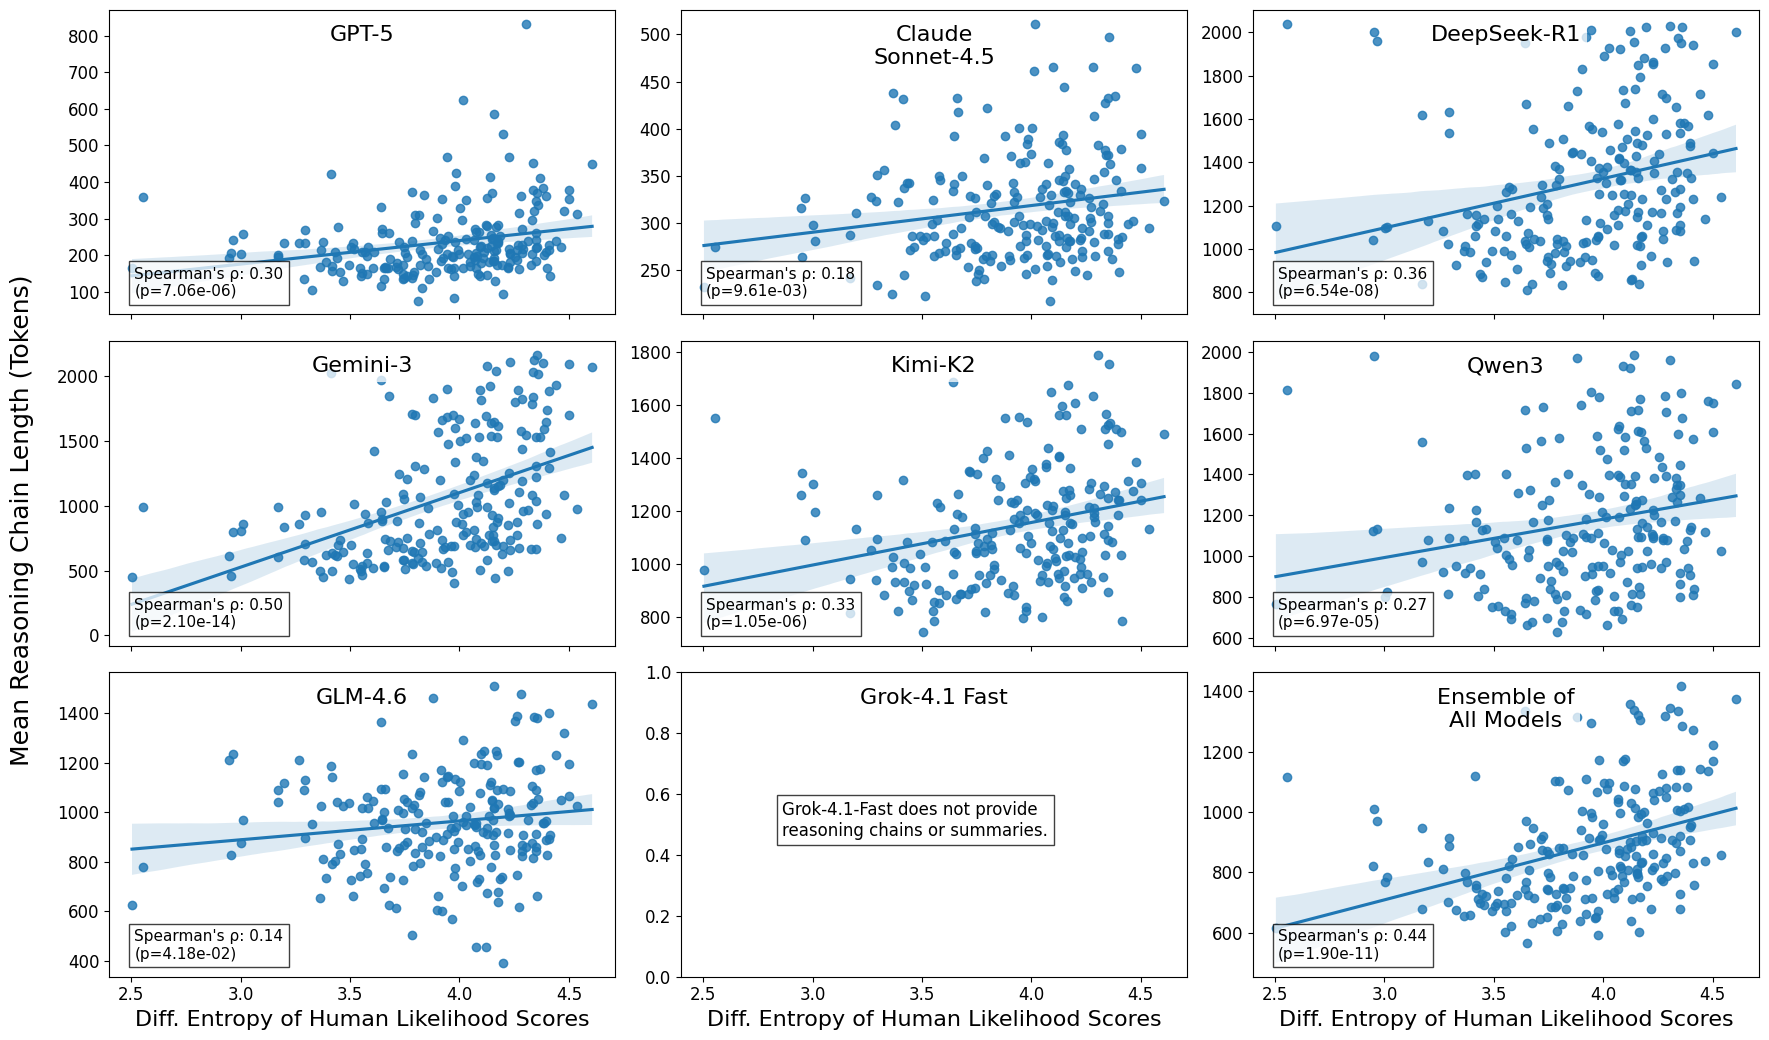

In [218]:
model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
'claude-sonnet-4.5': 'Claude\nSonnet-4.5', 
'Qwen3-235B-Thinking': 'Qwen3', 
'DeepSeek-R1': 'DeepSeek-R1',
'gemini-3-pro-preview': 'Gemini-3', 
'Kimi-K2-Thinking': 'Kimi-K2', 
'GLM-4.6': 'GLM-4.6',
'Ensemble of All Models': 'Ensemble of\nAll Models'
                               }

# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns
fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 3.5*n_rows))
measure = 'diff_entropy'

if n_rows > 1:
    axs = axs.flatten()

for i, model in enumerate(models):
    grouped = model_results[model].groupby(['UID']).agg({'reasoning_token_count': 'mean', f'human_{measure}_response': 'mean'}).reset_index()
    
    # Place title as text inside the plot (top-center)
    formatted_name = model_to_formatted_name.get(model, model)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes,
                fontsize=16, va='top', ha='center',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    axs[i].set_title('')
    
    if 'grok' in model:
        axs[i].text(0.20, 0.45, "Grok-4.1-Fast does not provide\nreasoning chains or summaries.", transform=axs[i].transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.75))
        # Still handle axis labels for grok
        if i % n_columns == 0:
            axs[i].set_ylabel("", fontsize=16)
        else:
            axs[i].set_ylabel('')
        row = i // n_columns
        if row == n_rows - 1:
            axs[i].set_xlabel("Diff. Entropy of Human Likelihood Scores", fontsize=16)
            axs[i].set_xlim(axs[0].get_xlim())
        else:
            axs[i].set_xlabel('')
            axs[i].set_xticklabels([])
        axs[i].tick_params(labelsize=12)
        continue
    
    sns.regplot(data=grouped, x=f'human_{measure}_response', y='reasoning_token_count', ax=axs[i], lowess=False)
    
    # Only show y-axis label on leftmost plots
    if i % n_columns == 0:
        axs[i].set_ylabel("")
    else:
        axs[i].set_ylabel('')
    
    # Only show x-axis label on bottom row
    row = i // n_columns
    if row == n_rows - 1:
        axs[i].set_xlabel("Diff. Entropy of Human Likelihood Scores", fontsize=16)
    else:
        axs[i].set_xlabel('')
        axs[i].set_xticklabels([])
    
    axs[i].tick_params(labelsize=12)
    
    # Spearman rho — position below the title text
    correlation = stats.spearmanr(grouped[f'human_{measure}_response'], grouped['reasoning_token_count'])
    axs[i].text(0.05, 0.05, f"Spearman's ρ: {correlation[0]:.2f}\n(p={correlation[1]:.2e})", 
                transform=axs[i].transAxes, fontsize=11, verticalalignment='bottom', 
                bbox=dict(facecolor='white', alpha=0.75))

# Ensemble plot
ensemble_idx = len(models)
ensemble_grouped = joint_model_results[joint_model_results['source'] != 'human'].groupby(['UID']).agg({'reasoning_token_count': 'mean', f'human_{measure}_response': 'mean'}).reset_index()
ensemble_grouped['reasoning_token_count'] = ensemble_grouped['reasoning_token_count'].apply(lambda x: float(x))
ensemble_grouped['human_diff_entropy_response'] = ensemble_grouped['human_diff_entropy_response'].apply(lambda x: float(x))

sns.regplot(data=ensemble_grouped, x=f'human_{measure}_response', y='reasoning_token_count', ax=axs[ensemble_idx], lowess=False)

axs[ensemble_idx].text(0.5, 0.95, 'Ensemble of\nAll Models', transform=axs[ensemble_idx].transAxes,
                       fontsize=16, va='top', ha='center',
                       bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
axs[ensemble_idx].set_title('')

if ensemble_idx % n_columns == 0:
    axs[ensemble_idx].set_ylabel("", fontsize=16)
else:
    axs[ensemble_idx].set_ylabel('')

# Ensemble is in the last row, so show x label
axs[ensemble_idx].set_xlabel("Diff. Entropy of Human Likelihood Scores", fontsize=16)
axs[ensemble_idx].tick_params(labelsize=12)

correlation = stats.spearmanr(ensemble_grouped[f'human_{measure}_response'], ensemble_grouped['reasoning_token_count'])
axs[ensemble_idx].text(0.05, 0.05, f"Spearman's ρ: {correlation[0]:.2f}\n(p={correlation[1]:.2e})", 
                       transform=axs[ensemble_idx].transAxes, fontsize=11, verticalalignment='bottom', 
                       bbox=dict(facecolor='white', alpha=0.75))

# Add x-axis labels to any other plots in the last row
last_row_start = (n_rows - 1) * n_columns
for j in range(last_row_start, last_row_start + n_columns):
    if j < len(axs) and axs[j].get_visible():
        axs[j].set_xlabel("Diff. Entropy of Human Likelihood Scores", fontsize=16)

# Add shared y-axis label for entire grid
fig.supylabel("Mean Reasoning Chain Length (Tokens)", fontsize=18)

# Hide unused subplots
for j in range(len(models) + 1, n_rows * n_columns):
    axs[j].set_visible(False)

plt.subplots_adjust(hspace=0.1, wspace=0.25)
plt.tight_layout()
# Add a bit of space for the y-axis label:
plt.subplots_adjust(left=0.075)
plt.savefig(f"./plots/reasoning_chain_length_vs_human_diff_entropy_ALL.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Plot: Reasoning Chain Length vs Human Entropy (One Model Only)

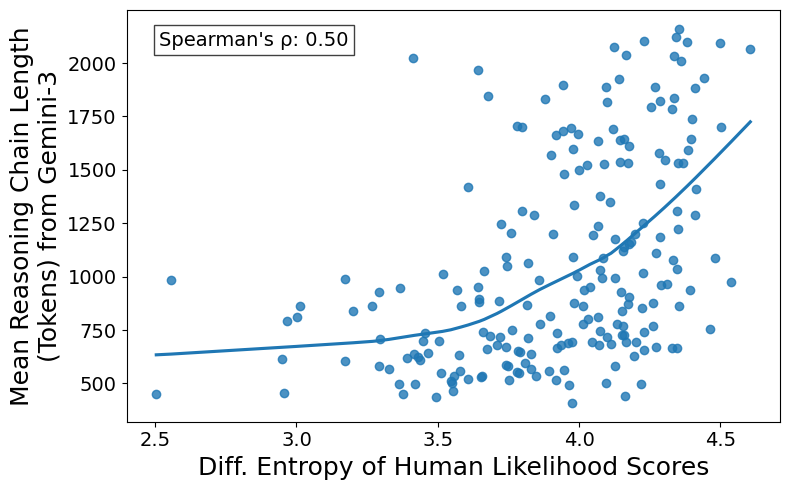

In [219]:
# One single model:
selected_model = 'gemini-3-pro-preview'
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3'}
fig,axs = plt.subplots(1,1,figsize=(8,5))

measure = 'diff_entropy'

grouped = model_results[selected_model].groupby(['UID']).agg({'reasoning_chain_length': 'mean', f'human_{measure}_response': 'mean'}).reset_index()
sns.regplot(data=grouped, x=f'human_{measure}_response', y='reasoning_chain_length', ax=axs, lowess=True)
axs.set_xlabel(f"Diff. Entropy of Human Likelihood Scores", fontsize=18)
axs.set_ylabel(f"Mean Reasoning Chain Length\n(Tokens) from {model_to_formatted_name[selected_model]}", fontsize=18)
# axs.set_title(model_to_formatted_name[selected_model], fontsize=18)
axs.tick_params(labelsize=14)
correlation = stats.spearmanr(grouped[f'human_{measure}_response'], grouped['reasoning_chain_length'])
axs.text(0.05, 0.95, f"Spearman's ρ: {correlation[0]:.2f}", transform=axs.transAxes, fontsize=14, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.75))
plt.tight_layout()

plt.savefig(f"./plots/model_vs_human_entropy_vs_reasoning_chain_length_{selected_model}.pdf", dpi=300)
plt.show()


## Bonus Plot: Reasoning Chain Lengths vs Models' Median Response

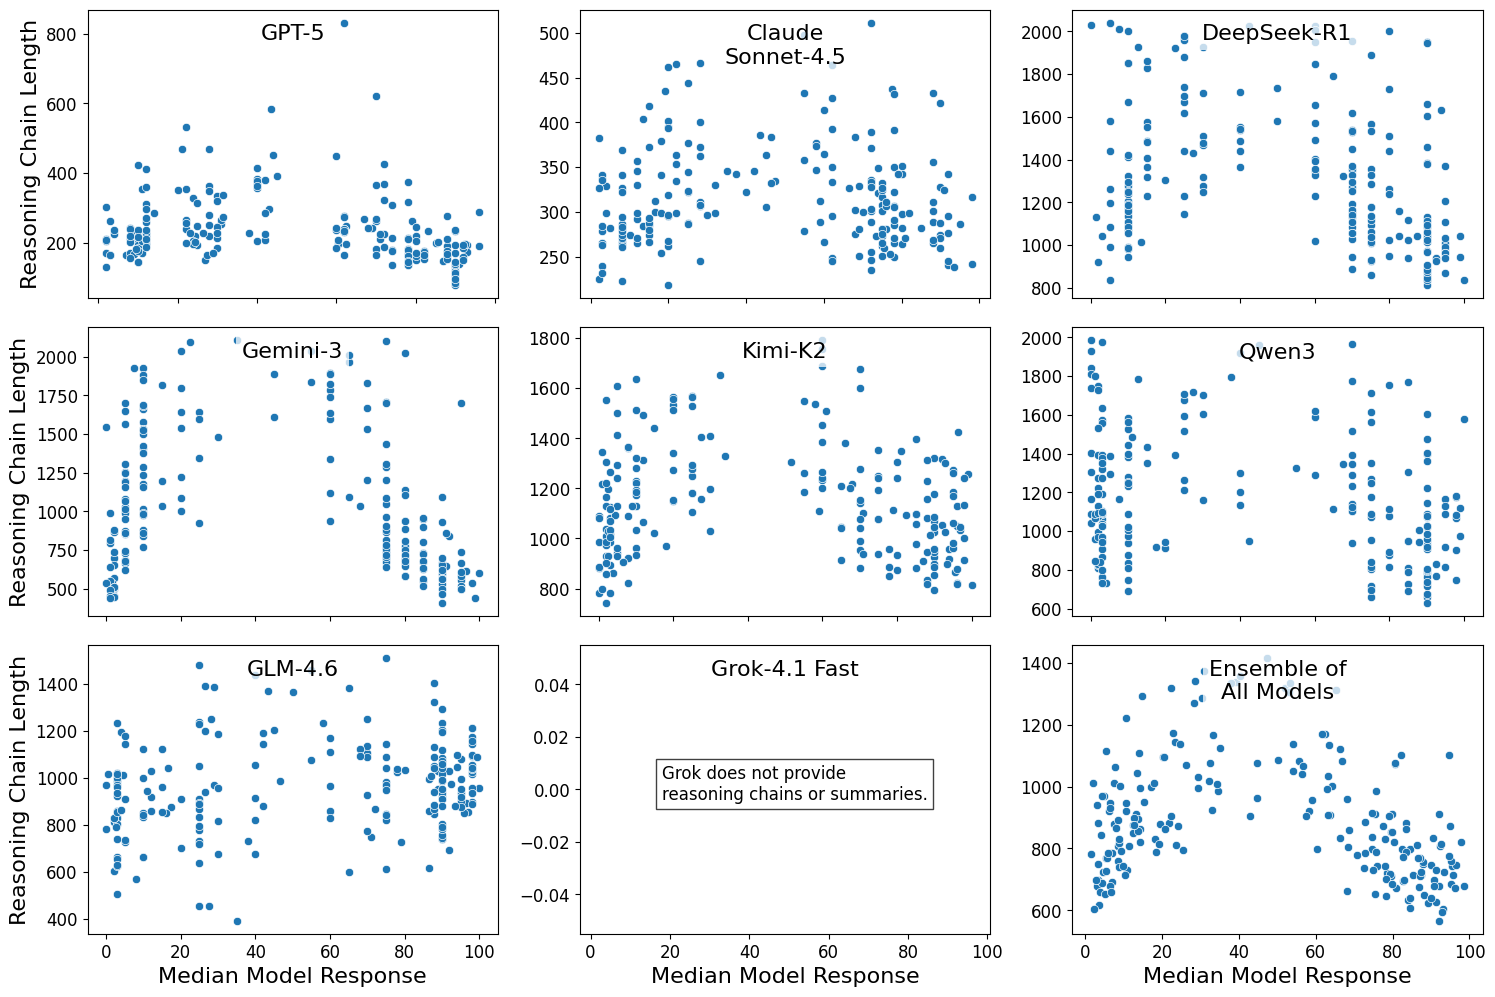

In [220]:
model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
'claude-sonnet-4.5': 'Claude\nSonnet-4.5', 
'Qwen3-235B-Thinking': 'Qwen3', 
'DeepSeek-R1': 'DeepSeek-R1',
'gemini-3-pro-preview': 'Gemini-3', 
'Kimi-K2-Thinking': 'Kimi-K2', 
'GLM-4.6': 'GLM-4.6',
'Ensemble of All Models': 'Ensemble of\nAll Models'
                               }

# Calculate grid dimensions with max 3 columns
n_columns = min(len(models), 3)
n_rows = (len(models) + 1 + n_columns - 1) // n_columns  # Ceiling division; add an extra spot for the ensemble

fig, axs = plt.subplots(n_rows, n_columns, figsize=(6*n_columns, 4*n_rows))
# Flatten axs array for easier indexing if it's 2D
if n_rows > 1:
    axs = axs.flatten()

# Determine shared x-axis limits across all data first (optional, adjust as needed)
all_indices = list(range(len(models))) + [len(models)]  # model indices + ensemble index

for i, model in enumerate(models):
    model_specific_results = joint_model_results[joint_model_results['source']==model]
    model_specific_results_grouped = model_specific_results.groupby(['UID']).agg({'reasoning_token_count': 'mean', 'response': 'median'}).reset_index()
    sns.scatterplot(data=model_specific_results_grouped, x='response', y='reasoning_token_count', ax=axs[i])
    
    # Place title as text inside the plot (top-center)
    formatted_name = model_to_formatted_name.get(model, model)
    axs[i].text(0.5, 0.95, formatted_name, transform=axs[i].transAxes,
                fontsize=16, va='top', ha='center',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    axs[i].set_title('')  # Remove external title
    
    # Only show y-axis label on leftmost plots
    if i % n_columns == 0:
        axs[i].set_ylabel("Reasoning Chain Length", fontsize=16)
    else:
        axs[i].set_ylabel('')
    
    # Only show x-axis label on bottom row
    row = i // n_columns
    if row == n_rows - 1:
        axs[i].set_xlabel("Median Model Response", fontsize=16)
    else:
        axs[i].set_xlabel('')
        axs[i].set_xticklabels([])
    
    axs[i].tick_params(labelsize=12)
    
    if 'grok' in model:
        axs[i].text(0.20, 0.45, "Grok does not provide\nreasoning chains or summaries.", transform=axs[i].transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.75))
        # Get x-ticks from any other subplot
        axs[i].set_xlim(axs[0].get_xlim())

# Ensemble plot
ensemble_idx = len(models)
ensemble_results = joint_model_results.groupby(['UID']).agg({'reasoning_token_count': 'mean', 'response': 'mean'}).reset_index()
sns.scatterplot(data=ensemble_results, x='response', y='reasoning_token_count', ax=axs[ensemble_idx])

axs[ensemble_idx].text(0.5, 0.95, 'Ensemble of\nAll Models', transform=axs[ensemble_idx].transAxes,
                       fontsize=16, va='top', ha='center',
                       bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
axs[ensemble_idx].set_title('')

ensemble_row = ensemble_idx // n_columns
if ensemble_idx % n_columns == 0:
    axs[ensemble_idx].set_ylabel("Reasoning Chain Length", fontsize=16)
else:
    axs[ensemble_idx].set_ylabel('')

# Ensemble is in the last row, so show x label
axs[ensemble_idx].set_xlabel("Median Model Response", fontsize=16)
axs[ensemble_idx].tick_params(labelsize=12)

# Also add x-axis labels to any other plots in the last row that didn't get them
# (plots in the same row as the ensemble)
last_row_start = (n_rows - 1) * n_columns
for j in range(last_row_start, last_row_start + n_columns):
    if j < len(axs) and axs[j].get_visible():
        axs[j].set_xlabel("Median Model Response", fontsize=16)

# Hide unused subplots
for j in range(ensemble_idx + 1, n_rows * n_columns):
    axs[j].set_visible(False)

plt.subplots_adjust(hspace=0.1, wspace=0.2)
plt.savefig(f"./plots/reasoning_chain_length_vs_median_model_response_ALL.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Joint Plot: Four Comparisons of Gemini-3 vs Humans (Figure 4)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/273031345.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


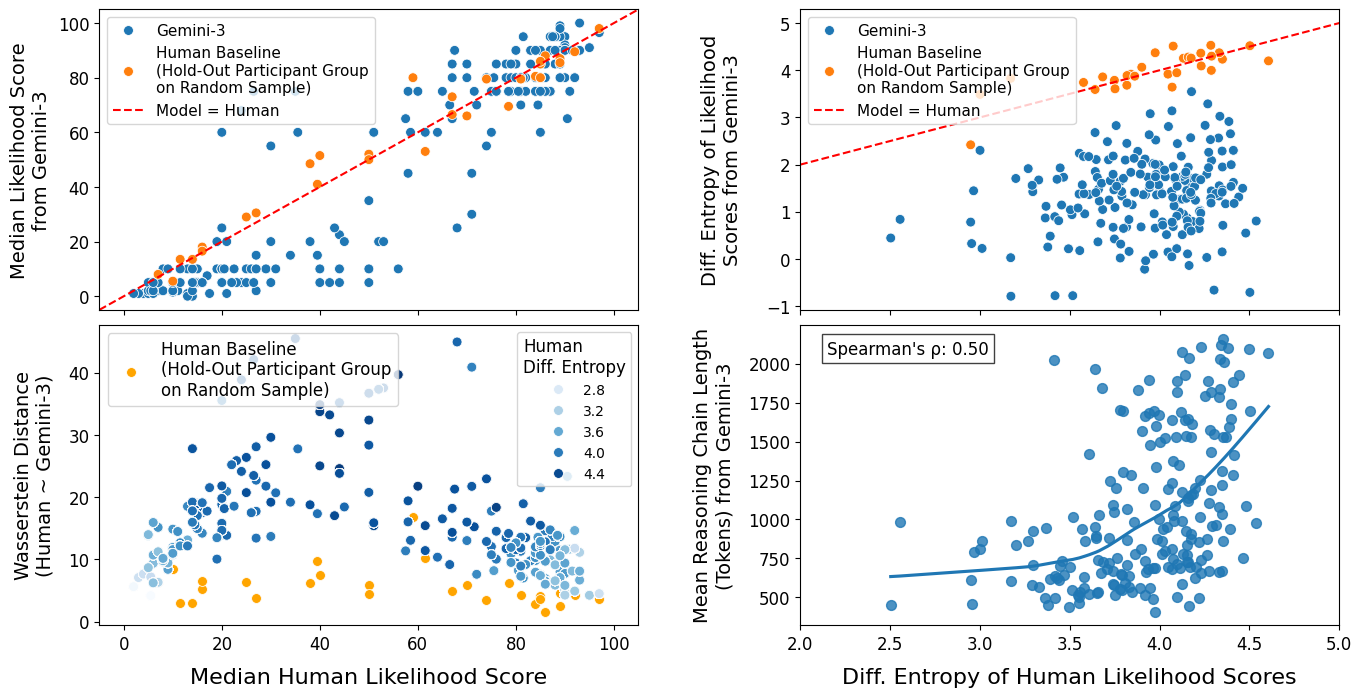

In [221]:
from matplotlib.lines import Line2D

selected_model = 'gemini-3-pro-preview'
model_to_formatted_name = {'gemini-3-pro-preview': 'Gemini-3'}
model_label = model_to_formatted_name[selected_model]
human_validation_color = 'orange'
baseline_label = 'Human Baseline\n(Hold-Out Participant Group\non Random Sample)'

# Create 2x2 subplot grid with shared x-axes within columns
# Adjust hspace (vertical spacing between rows) and wspace (horizontal spacing between columns)
# hspace: 0 = no space, 0.5 = 50% of subplot height, etc.
# wspace: 0 = no space, 0.5 = 50% of subplot width, etc.
fig, axs = plt.subplots(2, 2, figsize=(16, 8), 
                        sharex='col',
                        gridspec_kw={'hspace': 0.05, 'wspace': 0.3})

# ============================================================================
# TOP-LEFT: Median Comparison
# ============================================================================
measure = 'median'
agg_grouped = joint_results.groupby(['UID', 'source']).agg({f'{measure}_response': 'first'}).reset_index()
agg_grouped_for_plotting = agg_grouped.pivot(index='UID', columns='source', values=f'{measure}_response').reset_index(drop=True)
agg_grouped_for_plotting_selected_model = agg_grouped_for_plotting[['human', selected_model]].copy()

# Human validation medians
human_validation_grouped = human_validation_results.groupby(['UID']).agg(
    {'human_median_response': 'first', 'response': 'median'}
).reset_index()
human_validation_grouped['type'] = baseline_label

# Model vs human medians in same schema
df_model = agg_grouped_for_plotting_selected_model.copy()
df_model['human_median_response'] = df_model['human']
df_model['response'] = df_model[selected_model]
df_model['type'] = model_label

# Combine model + human-baseline
temp_grouped_median = pd.concat(
    [
        df_model[['human_median_response', 'response', 'type']],
        human_validation_grouped[['human_median_response', 'response', 'type']]
    ],
    ignore_index=True
)

sns.scatterplot(
    data=temp_grouped_median,
    x='human_median_response',
    y='response',
    hue='type',
    hue_order=[model_label, baseline_label],
    ax=axs[0, 0],
    s=50
)

# y = x reference line
y_equals_x_line_median = axs[0, 0].axline(
    xy1=(0, 0),
    xy2=(100, 100),
    color='red',
    linestyle='--'
)

axs[0, 0].set_xlabel("")  # Remove xlabel from top subplot (shared with bottom)
axs[0, 0].set_ylabel(f"Median Likelihood Score\nfrom {model_label}", fontsize=14, labelpad=5)
axs[0, 0].tick_params(labelsize=12)

# axs[0, 0].set_title("(A) Median Response Comparison", fontsize=16, fontweight='bold', loc='left')

# Legend
handles_median, labels_median = axs[0, 0].get_legend_handles_labels()
handles_median.append(y_equals_x_line_median)
labels_median.append('Model = Human')
axs[0, 0].legend(handles_median, labels_median, fontsize=11, loc='upper left')

# ============================================================================
# BOTTOM-LEFT: Wasserstein Distance
# ============================================================================
measure = 'median'

# Human baseline scatter
sns.scatterplot(
    data=human_validation_results,
    x='human_median_response',
    y='wasserstein_distance_from_human',
    ax=axs[1, 0],
    color=human_validation_color,
    label=baseline_label,
    s=50
)

# Model scatter with entropy hue
sns.scatterplot(
    data=model_results[selected_model],
    x=f'human_{measure}_response',
    y='wasserstein_distance_from_human',
    hue='human_diff_entropy_response',
    palette='Blues',
    ax=axs[1, 0],
    s=50
)

axs[1, 0].set_xlabel(f"{measure.capitalize()} Human Likelihood Score", fontsize=16, labelpad=10)
axs[1, 0].set_ylabel(f"Wasserstein Distance\n(Human ~ {model_label})", fontsize=14, labelpad=10)
axs[1, 0].tick_params(labelsize=12)
# axs[1, 0].set_title("(B) Wasserstein Distance Comparison", fontsize=16, fontweight='bold', loc='left')

# Grab all handles/labels from the auto legend
handles_wass, labels_wass = axs[1, 0].get_legend_handles_labels()

# First is baseline, rest are entropy levels
baseline_handle_wass = handles_wass[0]
baseline_label_wass = labels_wass[0]
entropy_handles_wass = handles_wass[1:]
entropy_labels_wass = labels_wass[1:]

# Create two separate legends
legend1_wass = axs[1, 0].legend(
    entropy_handles_wass,
    entropy_labels_wass,
    title='Human\nDiff. Entropy',
    fontsize=10,
    title_fontsize=12,
    loc='upper right'
)
axs[1, 0].add_artist(legend1_wass)

# Second legend for baseline
axs[1, 0].legend(
    [baseline_handle_wass],
    [baseline_label_wass],
    fontsize=12,
    loc='upper left'
)

# ============================================================================
# TOP-RIGHT: Differential Entropy
# ============================================================================
measure = 'diff_entropy'

entropy_grouped = joint_results.groupby(['UID', 'source']).agg({'diff_entropy_response': 'first'}).reset_index()
entropy_grouped_for_plotting = entropy_grouped.pivot(index='UID', columns='source', values='diff_entropy_response').reset_index(drop=True)
entropy_grouped_for_plotting_selected_model = entropy_grouped_for_plotting[['human', selected_model]].copy()

# Human validation data
human_validation_grouped_entropy = human_validation_results.groupby(['UID']).agg(
    {'human_diff_entropy_response': 'first', 'diff_entropy_response': 'first'}
).reset_index()
human_validation_grouped_entropy['type'] = baseline_label

# Model vs human data
entropy_grouped_for_plotting_selected_model['human_diff_entropy_response'] = entropy_grouped_for_plotting_selected_model['human']
entropy_grouped_for_plotting_selected_model['diff_entropy_response'] = entropy_grouped_for_plotting_selected_model[selected_model]
entropy_grouped_for_plotting_selected_model['type'] = model_label

temp_grouped_entropy = pd.concat(
    [
        human_validation_grouped_entropy,
        entropy_grouped_for_plotting_selected_model[
            ['human_diff_entropy_response', 'diff_entropy_response', 'type']
        ]
    ],
    ignore_index=True
)

sns.scatterplot(
    data=temp_grouped_entropy,
    x='human_diff_entropy_response',
    y='diff_entropy_response',
    hue='type',
    hue_order=[model_label, baseline_label],
    ax=axs[0, 1],
    s=50
)

y_equals_x_line_entropy = axs[0, 1].axline(xy1=(0, 0), xy2=(5, 5), color='red', linestyle='--')
axs[0, 1].set_xlabel("")  # Remove xlabel from top subplot (shared with bottom)
axs[0, 1].set_ylabel(f"Diff. Entropy of Likelihood\nScores from {model_label}", fontsize=14, labelpad=17)
axs[0, 1].tick_params(labelsize=12)
axs[0, 1].set_xlim(2,5)
# axs[0, 1].set_title("(C) Differential Entropy Comparison", fontsize=16, fontweight='bold', loc='left')

# Legend
handles_entropy, labels_entropy = axs[0, 1].get_legend_handles_labels()
handles_entropy.append(y_equals_x_line_entropy)
labels_entropy.append('Model = Human')
axs[0, 1].legend(handles_entropy, labels_entropy, fontsize=11, loc='upper left')

# ============================================================================
# BOTTOM-RIGHT: Reasoning Chain Length vs Human Entropy
# ============================================================================
measure = 'diff_entropy'

grouped_reasoning = model_results[selected_model].groupby(['UID']).agg({
    'reasoning_chain_length': 'mean', 
    f'human_{measure}_response': 'mean'
}).reset_index()

sns.regplot(
    data=grouped_reasoning, 
    x=f'human_{measure}_response', 
    y='reasoning_chain_length', 
    ax=axs[1, 1], 
    lowess=True,
    scatter_kws={'s': 50}
)

axs[1, 1].set_xlabel(f"Diff. Entropy of Human Likelihood Scores", fontsize=16, labelpad=10)
axs[1, 1].set_ylabel(f"Mean Reasoning Chain Length\n(Tokens) from {model_label}", fontsize=14, labelpad=10)
axs[1, 1].tick_params(labelsize=12)
axs[1, 1].set_xlim(2,5)
# axs[1, 1].set_title("(D) Reasoning Chain Length vs Human Entropy", fontsize=16, fontweight='bold', loc='left')

correlation = stats.spearmanr(grouped_reasoning[f'human_{measure}_response'], grouped_reasoning['reasoning_chain_length'])
axs[1, 1].text(
    0.05, 0.95, 
    f"Spearman's ρ: {correlation[0]:.2f}", 
    transform=axs[1, 1].transAxes, 
    fontsize=12, 
    verticalalignment='top', 
    bbox=dict(facecolor='white', alpha=0.75)
)

plt.tight_layout()
plt.savefig("./plots/gemini_joint_four_comparisons.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Plot: Model Responses with Different Sampling Temperatures (Figure 13)

In [222]:
## Read in the temperature experiments data

models = ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']
temperature_ablation_df_list = []
for model in models:
    for temperature in [0.4, 0.8, 1.2, 1.6, 2.0]:
        if os.path.exists(f"./results/temperature_experiments/{model}_temperature_{temperature:.1f}.jsonl"):
            temperature_ablation_data = pd.read_json(f"./results/temperature_experiments/{model}_temperature_{temperature:.1f}.jsonl", lines=True)
            temperature_ablation_data['temperature'] = temperature
            temperature_ablation_data['source'] = model
            temperature_ablation_df_list.append(temperature_ablation_data)
            


In [223]:
## Make copy of human validation results
human_validation_results_temperature_ablation = human_validation_results.copy()

In [224]:
## Annotate:

for temperature_ablation_df in temperature_ablation_df_list:
    temperature_ablation_df['response'] = temperature_ablation_df['answer'].apply(attempt_digit_conversion)
    temperature_ablation_df['median_response'] = temperature_ablation_df.groupby(['UID'])['response'].transform('median')
    temperature_ablation_df['mean_response'] = temperature_ablation_df.groupby(['UID'])['response'].transform('mean')
    temperature_ablation_df['std_response'] = temperature_ablation_df.groupby(['UID'])['response'].transform('std')
    temperature_ablation_df['diff_entropy_response'] = temperature_ablation_df.groupby(['UID'])['response'].transform(estimate_differential_entropy)

for temperature_ablation_df in temperature_ablation_df_list:
    temperature_ablation_df['wasserstein_distance_from_human'] = temperature_ablation_df.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=temperature_ablation_df))
    temperature_ablation_df['human_median_response'] = temperature_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    temperature_ablation_df['human_mean_response'] = temperature_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    temperature_ablation_df['human_std_response'] = temperature_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    temperature_ablation_df['human_diff_entropy_response'] = temperature_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))

human_validation_results_temperature_ablation['wasserstein_distance_from_human'] = human_validation_results.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=human_validation_results_temperature_ablation))
median_human_validation_wasserstein_distance = human_validation_results_temperature_ablation['wasserstein_distance_from_human'].median()

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values wil

In [225]:
# Some more stitching together:

joint_temperature_ablation_model_results = pd.concat(temperature_ablation_df_list).reset_index(drop=True)

human_results_for_temperature = human_results[human_results['UID'].isin(joint_temperature_ablation_model_results['UID'].unique())].copy()
human_results_for_temperature['temperature'] = 'human'
joint_temperature_ablation_results = pd.concat([joint_temperature_ablation_model_results, human_results_for_temperature]).reset_index(drop=True)

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/3270553454.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/3270553454.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)


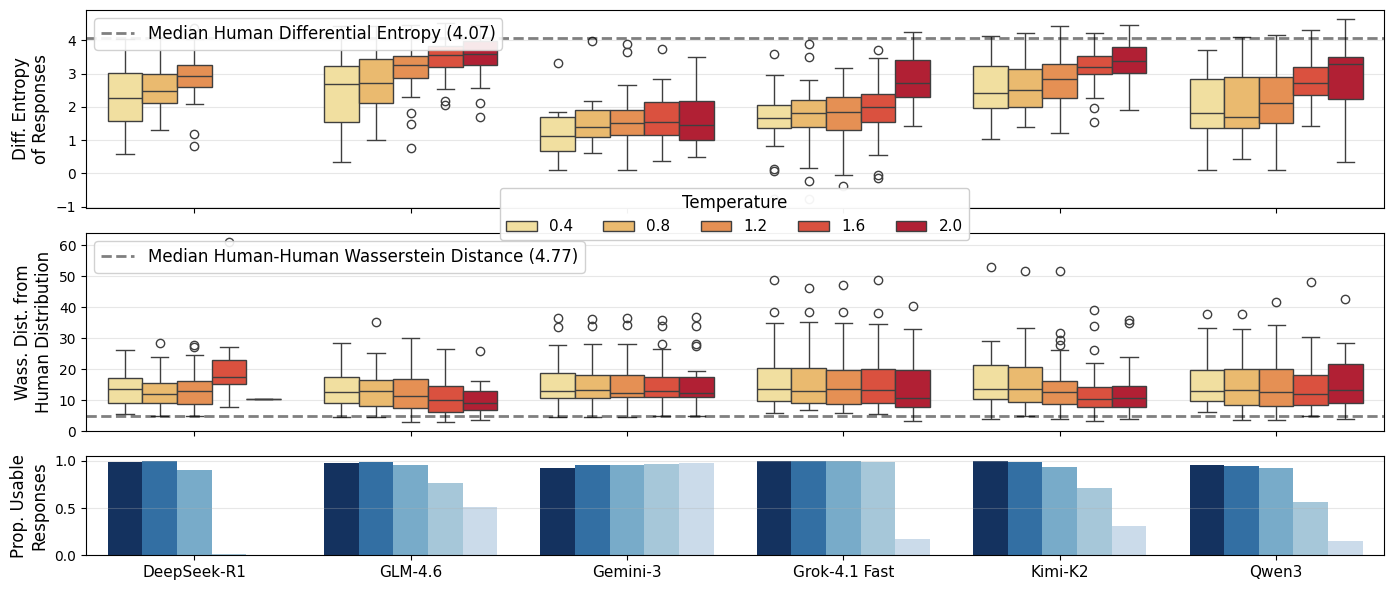

In [226]:
## Unified Plot: Entropy, Wasserstein Distance, and Proportion Usable Data

model_to_formatted_name = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4.5': 'Claude Sonnet-4.5',
    'DeepSeek-R1': 'DeepSeek-R1',
    'gemini-3-pro-preview': 'Gemini-3',
    'Kimi-K2-Thinking': 'Kimi-K2',
    'Qwen3-235B-Thinking': 'Qwen3',
    'GLM-4.6': 'GLM-4.6',
    'grok-4.1-fast': 'Grok-4.1 Fast',
    'human': 'human'
}

# Create a copy to avoid modifying the original dataframe
joint_temperature_ablation_results_plot = joint_temperature_ablation_results.copy()
joint_temperature_ablation_results_plot['source'] = joint_temperature_ablation_results_plot['source'].map(model_to_formatted_name)

# Prepare data
temperature_ablation_models = [x for x in joint_temperature_ablation_results_plot['source'].unique() if x != 'human']

# Filter out human data from the grouped data
model_data_only = joint_temperature_ablation_results_plot[joint_temperature_ablation_results_plot['source'] != 'human']

# Create grouped data for entropy and wasserstein
grouped_data = model_data_only.groupby(['source', 'temperature', 'UID']).agg({
    'diff_entropy_response': 'first',
    'wasserstein_distance_from_human': 'first'
}).reset_index()


# Calculate median human differential entropy for the horizontal line
human_data = joint_temperature_ablation_results_plot[joint_temperature_ablation_results_plot['source'] == 'human']
median_human_entropy = human_data['diff_entropy_response'].median()

# Calculate proportion usable data for each model-temperature combination
usable_data_dict = {}
for model in temperature_ablation_models:
    model_data = joint_temperature_ablation_results_plot[joint_temperature_ablation_results_plot['source'] == model]
    for temperature in [0.4, 0.8, 1.2, 1.6, 2.0]:
        temp_data = model_data[model_data['temperature'] == temperature]
        if len(temp_data) > 0:
            prop_usable = np.mean(~pd.isna(temp_data['response']))
            usable_data_dict[(model, temperature)] = prop_usable

# Create figure with 3 rows, shared x-axis, with custom height ratios
fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, 
                        gridspec_kw={'height_ratios': [2, 2, 1]})

# Define color palette for temperatures using a warm gradient
import matplotlib.cm as cm
temps = [0.4, 0.8, 1.2, 1.6, 2.0]
cmap = cm.get_cmap('YlOrRd')
temperature_colors = {temp: cmap((i+1)/(len(temps)+1)) for i, temp in enumerate(temps)}
temperature_colors['human'] = '#8c564b'

# Row 1: Entropy boxplots
sns.boxplot(data=grouped_data, y='diff_entropy_response', x='source', 
            hue='temperature', ax=axs[0], palette=temperature_colors)
human_line_entropy = axs[0].axhline(y=median_human_entropy, color='black', linestyle='--', 
                             linewidth=2, alpha=0.5)
axs[0].set_ylabel('Diff. Entropy\nof Responses', fontsize=12)
axs[0].set_xlabel('')
# Create custom legend with only the human median line
axs[0].legend([human_line_entropy], [f'Median Human Differential Entropy ({median_human_entropy:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[0].grid(axis='y', alpha=0.3)

# Row 2: Wasserstein distance boxplots
sns.boxplot(data=grouped_data, y='wasserstein_distance_from_human', x='source', 
            hue='temperature', ax=axs[1], palette=temperature_colors)
human_line_wasserstein = axs[1].axhline(y=median_human_validation_wasserstein_distance, color='black', linestyle='--', 
                             linewidth=2, alpha=0.5)
axs[1].set_ylabel('Wass. Dist. from\nHuman Distribution', fontsize=12)
axs[1].set_xlabel('')
axs[1].legend([human_line_wasserstein], [f'Median Human-Human Wasserstein Distance ({median_human_validation_wasserstein_distance:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[1].grid(axis='y', alpha=0.3)

# Row 3: Proportion usable data bars
# Need to structure this data properly for grouped bar plot
usable_data_list = []
for model in temperature_ablation_models:
    for temp in [0.4, 0.8, 1.2, 1.6, 2.0]:
        if (model, temp) in usable_data_dict:
            usable_data_list.append({
                'source': model,
                'temperature': temp,
                'proportion_usable': usable_data_dict[(model, temp)]
            })
usable_data_df = pd.DataFrame(usable_data_list)

# Create a blue gradient palette for the bottom plot
blue_gradient_palette = {0.4: '#08306b', 0.8: '#2171b5', 1.2: '#6baed6', 
                         1.6: '#9ecae1', 2.0: '#c6dbef'}

sns.barplot(data=usable_data_df, x='source', y='proportion_usable', 
            hue='temperature', ax=axs[2], palette=blue_gradient_palette, width=0.8)
axs[2].set_ylabel('Prop. Usable\nResponses', fontsize=12)
axs[2].set_xlabel('', fontsize=12)
axs[2].set_ylim(0, 1.05)
axs[2].grid(axis='y', alpha=0.3)
axs[2].legend_.remove()

# Rotate x-axis labels for bottom plot
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)

# Add legend to the middle subplot
# Add temperature legend between top and middle rows
handles, labels = axs[1].get_legend_handles_labels()
legend = fig.legend(handles, labels, title='Temperature', 
                    bbox_to_anchor=(0.525, 0.635), loc='center', 
                    ncol=5, fontsize=11, title_fontsize=12, framealpha=0.95, 
                    bbox_transform=fig.transFigure)

plt.tight_layout()
plt.savefig('./plots/unified_temperature_ablation.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Plot & Statistical Test: Model Responses with Different Reasoning Efforts (Figure 14)

In [227]:
# Reading in the reasoning effort data:

models = ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']
reasoning_effort_ablation_df_list = []
for model in models:
    for reasoning_effort in ["low", "medium", "high"]:
        if os.path.exists(f"./results/reasoning_effort_experiments/{model}_reasoning_effort_{reasoning_effort}.jsonl"):
            reasoning_effort_ablation_data = pd.read_json(f"./results/reasoning_effort_experiments/{model}_reasoning_effort_{reasoning_effort}.jsonl", lines=True)
            reasoning_effort_ablation_data['reasoning_effort'] = reasoning_effort
            reasoning_effort_ablation_data['source'] = model
            reasoning_effort_ablation_df_list.append(reasoning_effort_ablation_data)
            


In [228]:
# Make copy of human validation results
human_validation_results_reasoning_effort_ablation = human_validation_results.copy()


In [229]:
## Annotate:

for reasoning_effort_ablation_df in reasoning_effort_ablation_df_list:
    reasoning_effort_ablation_df['response'] = reasoning_effort_ablation_df['answer'].apply(attempt_digit_conversion)
    reasoning_effort_ablation_df['median_response'] = reasoning_effort_ablation_df.groupby(['UID'])['response'].transform('median')
    reasoning_effort_ablation_df['mean_response'] = reasoning_effort_ablation_df.groupby(['UID'])['response'].transform('mean')
    reasoning_effort_ablation_df['std_response'] = reasoning_effort_ablation_df.groupby(['UID'])['response'].transform('std')
    reasoning_effort_ablation_df['diff_entropy_response'] = reasoning_effort_ablation_df.groupby(['UID'])['response'].transform(estimate_differential_entropy)

for reasoning_effort_ablation_df in reasoning_effort_ablation_df_list:
    reasoning_effort_ablation_df['wasserstein_distance_from_human'] = reasoning_effort_ablation_df.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=reasoning_effort_ablation_df))
    reasoning_effort_ablation_df['human_median_response'] = reasoning_effort_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    reasoning_effort_ablation_df['human_mean_response'] = reasoning_effort_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    reasoning_effort_ablation_df['human_std_response'] = reasoning_effort_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    reasoning_effort_ablation_df['human_diff_entropy_response'] = reasoning_effort_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))

human_validation_results_reasoning_effort_ablation['wasserstein_distance_from_human'] = human_validation_results.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=human_validation_results_reasoning_effort_ablation))
median_human_validation_wasserstein_distance = human_validation_results_reasoning_effort_ablation['wasserstein_distance_from_human'].median()

joint_reasoning_effort_ablation_model_results = pd.concat(reasoning_effort_ablation_df_list).reset_index(drop=True)


In [230]:
# Some more stitching together:

human_results_for_reasoning_effort = human_results[human_results['UID'].isin(joint_reasoning_effort_ablation_model_results['UID'].unique())].copy()
human_results_for_reasoning_effort['reasoning_effort'] = 'human'
joint_reasoning_effort_ablation_results = pd.concat([joint_reasoning_effort_ablation_model_results, human_results_for_reasoning_effort]).reset_index(drop=True)


In [234]:
## Reading in the thinking budget data:

models = ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']
thinking_budget_ablation_df_list = []
for model in models:
    for thinking_budget in [512, 2048, 4096]:
        if os.path.exists(f"./results/reasoning_effort_experiments/{model}_thinking_budget_{thinking_budget}.jsonl"):
            thinking_budget_ablation_data = pd.read_json(f"./results/reasoning_effort_experiments/{model}_thinking_budget_{thinking_budget}.jsonl", lines=True)
            thinking_budget_ablation_data['thinking_budget'] = thinking_budget
            thinking_budget_ablation_data['source'] = model
            thinking_budget_ablation_df_list.append(thinking_budget_ablation_data)



In [236]:
## Annotate:

for thinking_budget_ablation_df in thinking_budget_ablation_df_list:
    thinking_budget_ablation_df['response'] = thinking_budget_ablation_df['answer'].apply(attempt_digit_conversion)
    thinking_budget_ablation_df['median_response'] = thinking_budget_ablation_df.groupby(['UID'])['response'].transform('median')
    thinking_budget_ablation_df['mean_response'] = thinking_budget_ablation_df.groupby(['UID'])['response'].transform('mean')
    thinking_budget_ablation_df['std_response'] = thinking_budget_ablation_df.groupby(['UID'])['response'].transform('std')
    thinking_budget_ablation_df['diff_entropy_response'] = thinking_budget_ablation_df.groupby(['UID'])['response'].transform(estimate_differential_entropy)

for thinking_budget_ablation_df in thinking_budget_ablation_df_list:
    thinking_budget_ablation_df['wasserstein_distance_from_human'] = thinking_budget_ablation_df.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=thinking_budget_ablation_df))
    thinking_budget_ablation_df['human_median_response'] = thinking_budget_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    thinking_budget_ablation_df['human_mean_response'] = thinking_budget_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    thinking_budget_ablation_df['human_std_response'] = thinking_budget_ablation_df['UID'].apply(lambda x: get_human_agg_response(x, 'std'))



In [237]:
# Stitch together the data:

joint_thinking_budget_ablation_model_results = pd.concat(thinking_budget_ablation_df_list).reset_index(drop=True)

In [238]:
## Combined Reasoning Effort + Thinking Budget Data

# Create a combined dataframe
# For reasoning effort data, create a combined column
re_data = joint_reasoning_effort_ablation_model_results.copy()
re_data['ablation_type'] = 'reasoning_effort'
re_data['ablation_value'] = re_data['reasoning_effort']

# For thinking budget data, create a combined column
tb_data = joint_thinking_budget_ablation_model_results.copy()
tb_data['ablation_type'] = 'thinking_budget'
tb_data['ablation_value'] = tb_data['thinking_budget'].astype(str)

# Combine the dataframes
joint_re_tb_results = pd.concat([re_data, tb_data], ignore_index=True)

# Add human data
human_results_for_thinking_budget = human_results[human_results['UID'].isin(joint_thinking_budget_ablation_model_results['UID'].unique())].copy()
human_results_for_thinking_budget['thinking_budget'] = 'human'
human_results_for_thinking_budget['source'] = 'human'
human_results_for_thinking_budget['reasoning_effort'] = 'human'
joint_re_tb_results = pd.concat([joint_re_tb_results, human_results_for_thinking_budget]).reset_index(drop=True)


/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/3008084606.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)


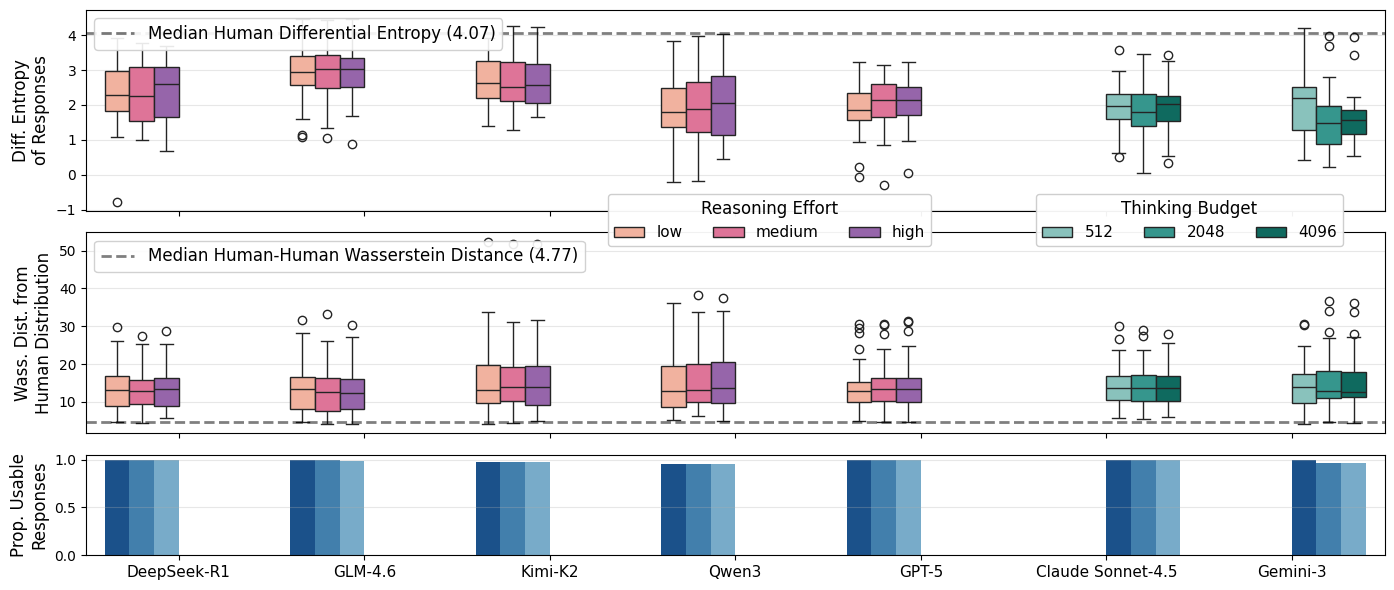

In [239]:
## Unified Plot: Reasoning Effort + Thinking Budget Combined

model_to_formatted_name = {'gpt-5': 'GPT-5', 
                               'grok-4.1-fast': 'Grok-4.1 Fast', 
                               'claude-sonnet-4.5': 'Claude Sonnet-4.5', 
                               'Qwen3-235B-Thinking': 'Qwen3', 
                               'DeepSeek-R1': 'DeepSeek-R1',
                               'gemini-3-pro-preview': 'Gemini-3', 
                               'Kimi-K2-Thinking': 'Kimi-K2', 
                               'GLM-4.6': 'GLM-4.6',
                               'Ensemble of All Models': 'Ensemble of All Models'
                               }

# Create a copy to avoid modifying the original dataframe
joint_re_tb_results_plot = joint_re_tb_results.copy()
joint_re_tb_results_plot['source'] = joint_re_tb_results_plot['source'].map(model_to_formatted_name)

# Prepare data
combined_models = [x for x in joint_re_tb_results_plot['source'].unique() if x != 'human']
# Define custom order for models (thinking budget models together)
model_order = ['DeepSeek-R1', 'GLM-4.6', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 
               'gpt-5', 'claude-sonnet-4.5', 'gemini-3-pro-preview']
model_order = [model_to_formatted_name[model] for model in model_order]

# Filter out human data
model_data_only_combined = joint_re_tb_results_plot[joint_re_tb_results_plot['source'] != 'human'].copy()

# Create a combined hue column that's model-specific to avoid centering issues
# This ensures each model has its own set of 3 values without gaps
model_data_only_combined['plot_hue'] = model_data_only_combined.apply(
    lambda row: row['ablation_value'] if row['ablation_type'] == 'reasoning_effort' 
    else f"TB_{row['ablation_value']}", axis=1
)

# Create grouped data for entropy and wasserstein
grouped_data_combined = model_data_only_combined.groupby(['source', 'ablation_type', 'ablation_value', 'plot_hue', 'UID']).agg({
    'diff_entropy_response': 'first',
    'wasserstein_distance_from_human': 'first'
}).reset_index()

# Calculate proportion usable data for each model-ablation combination
usable_data_dict_combined = {}
for model in combined_models:
    model_data = joint_re_tb_results_plot[joint_re_tb_results_plot['source'] == model]
    
    # Check reasoning effort values
    for effort in ['low', 'medium', 'high']:
        effort_data = model_data[model_data['reasoning_effort'] == effort]
        if len(effort_data) > 0:
            prop_usable = np.mean(~pd.isna(effort_data['response']))
            usable_data_dict_combined[(model, 'reasoning_effort', effort)] = prop_usable
    
    # Check thinking budget values
    for budget in [512, 2048, 4096]:
        budget_data = model_data[model_data['thinking_budget'] == budget]
        if len(budget_data) > 0:
            prop_usable = np.mean(~pd.isna(budget_data['response']))
            usable_data_dict_combined[(model, 'thinking_budget', str(budget))] = prop_usable

# Create figure with 3 rows, shared x-axis, with custom height ratios
fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, 
                        gridspec_kw={'height_ratios': [2, 2, 1]})

# Define color palettes
# Reasoning effort: peach -> pink -> purple gradient
reasoning_effort_colors_combined = {
    'low': '#FFAB91',      # Peach
    'medium': '#F06292',   # Pink
    'high': '#9B59B6'      # Purple
}

# Thinking budget: shades of teal/cyan
thinking_budget_colors_combined = {
    'TB_512': '#80CBC4',      # Light teal
    'TB_2048': '#26A69A',     # Medium teal
    'TB_4096': '#00796B'      # Dark teal
}

# Combine color palettes
combined_palette = {**reasoning_effort_colors_combined, **thinking_budget_colors_combined}

# Row 1: Entropy boxplots
sns.boxplot(data=grouped_data_combined, y='diff_entropy_response', x='source', 
            hue='plot_hue', hue_order=['low', 'medium', 'high', 'TB_512', 'TB_2048', 'TB_4096'],
            order=model_order,
            ax=axs[0], palette=combined_palette)
human_line_combined = axs[0].axhline(y=median_human_entropy, color='black', linestyle='--', 
                                      linewidth=2, alpha=0.5)
axs[0].set_ylabel('Diff. Entropy\nof Responses', fontsize=12)
axs[0].set_xlabel('')
# Create custom legend with only the human median line
axs[0].legend([human_line_combined], [f'Median Human Differential Entropy ({median_human_entropy:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[0].grid(axis='y', alpha=0.3)

# Row 2: Wasserstein distance boxplots
sns.boxplot(data=grouped_data_combined, y='wasserstein_distance_from_human', x='source', 
            hue='plot_hue', hue_order=['low', 'medium', 'high', 'TB_512', 'TB_2048', 'TB_4096'],
            order=model_order,
            ax=axs[1], palette=combined_palette)
human_line_wasserstein_combined = axs[1].axhline(y=median_human_validation_wasserstein_distance, color='black', linestyle='--', 
                             linewidth=2, alpha=0.5)
axs[1].set_ylabel('Wass. Dist. from\nHuman Distribution', fontsize=12)
axs[1].set_xlabel('')
axs[1].legend([human_line_wasserstein_combined], [f'Median Human-Human Wasserstein Distance ({median_human_validation_wasserstein_distance:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[1].grid(axis='y', alpha=0.3)

# Row 3: Proportion usable data bars
usable_data_list_combined = []
for model in combined_models:
    for effort in ['low', 'medium', 'high']:
        if (model, 'reasoning_effort', effort) in usable_data_dict_combined:
            usable_data_list_combined.append({
                'source': model,
                'ablation_type': 'reasoning_effort',
                'ablation_value': effort,
                'plot_hue': effort,
                'proportion_usable': usable_data_dict_combined[(model, 'reasoning_effort', effort)]
            })
    for budget in ['512', '2048', '4096']:
        if (model, 'thinking_budget', budget) in usable_data_dict_combined:
            usable_data_list_combined.append({
                'source': model,
                'ablation_type': 'thinking_budget',
                'ablation_value': budget,
                'plot_hue': f'TB_{budget}',
                'proportion_usable': usable_data_dict_combined[(model, 'thinking_budget', budget)]
            })
usable_data_df_combined = pd.DataFrame(usable_data_list_combined)

# Create blue gradient palettes for the bottom plot (same colors for both ablation types)
blue_gradient_palette_combined = {
    'low': '#08519c', 'medium': '#3182bd', 'high': '#6baed6',
    'TB_512': '#08519c', 'TB_2048': '#3182bd', 'TB_4096': '#6baed6'
}

sns.barplot(data=usable_data_df_combined, x='source', y='proportion_usable', 
            hue='plot_hue', hue_order=['low', 'medium', 'high', 'TB_512', 'TB_2048', 'TB_4096'],
            order=model_order,
            ax=axs[2], palette=blue_gradient_palette_combined, width=0.8)
axs[2].set_ylabel('Prop. Usable\nResponses', fontsize=12)
axs[2].set_xlabel('', fontsize=12)
axs[2].set_ylim(0, 1.05)
axs[2].grid(axis='y', alpha=0.3)
axs[2].legend_.remove()

# Rotate x-axis labels for bottom plot
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)

# Add legends between top and middle rows
handles, labels = axs[1].get_legend_handles_labels()

# Split handles and labels into reasoning effort and thinking budget
re_handles = []
re_labels = []
tb_handles = []
tb_labels = []

for handle, label in zip(handles, labels):
    if label in ['low', 'medium', 'high']:
        re_handles.append(handle)
        re_labels.append(label)
    elif label.startswith('TB_'):
        tb_handles.append(handle)
        # Clean up the label for display
        clean_label = label.replace('TB_', '')
        tb_labels.append(clean_label)

# Add reasoning effort legend
if re_handles:
    legend_re = fig.legend(re_handles, re_labels, title='Reasoning Effort', 
                          bbox_to_anchor=(0.55, 0.625), loc='center', 
                          ncol=3, fontsize=11, title_fontsize=12, framealpha=0.95, 
                          bbox_transform=fig.transFigure)

# Add thinking budget legend
if tb_handles:
    legend_tb = fig.legend(tb_handles, tb_labels, title='Thinking Budget', 
                          bbox_to_anchor=(0.85, 0.625), loc='center', 
                          ncol=3, fontsize=11, title_fontsize=12, framealpha=0.95, 
                          bbox_transform=fig.transFigure)


plt.tight_layout()
plt.savefig('./plots/unified_reasoning_effort_thinking_budget_ablation.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [240]:
## Statistical Tests Using Bootstrapped 95 CIs of Median Responses

np.random.seed(3535)

modelwise_prop_significant = {}

for model in joint_re_tb_results.source.unique():
    print(f"Model: {model}")
    model_indexed = joint_re_tb_results[joint_re_tb_results['source']==model]
    median_sig_tests = []
    for UID in tqdm(model_indexed['UID'].unique()):
        model_UID_indexed = model_indexed[model_indexed['UID'] == UID]
        low_budget = model_UID_indexed[model_UID_indexed['thinking_budget'] == 512]
        high_budget = model_UID_indexed[model_UID_indexed['thinking_budget'] == 4096]
        low_budget_median = low_budget['response'].median()
        high_budget_median = high_budget['response'].median()
        # Now, do bootstrap sampling to get a distribution of the median
        low_budget_bootstrap_medians = []
        high_budget_bootstrap_medians = []
        for _ in range(10000):
            low_budget_bootstrap_sample = np.random.choice(model_UID_indexed['response'], size=len(model_UID_indexed), replace=True)
            high_budget_bootstrap_sample = np.random.choice(model_UID_indexed['response'], size=len(model_UID_indexed), replace=True)
            low_budget_bootstrap_medians.append(np.median(low_budget_bootstrap_sample))
            high_budget_bootstrap_medians.append(np.median(high_budget_bootstrap_sample))
        low_budget_bootstrap_medians = np.array(low_budget_bootstrap_medians)
        high_budget_bootstrap_medians = np.array(high_budget_bootstrap_medians)
        low_budget_95_ci = np.percentile(low_budget_bootstrap_medians, [2.5, 97.5])
        high_budget_95_ci = np.percentile(high_budget_bootstrap_medians, [2.5, 97.5])
        # Significant if there is no overlap between the two 95% CIs
        significant = (low_budget_95_ci[1] < high_budget_95_ci[0]) or (high_budget_95_ci[1] < low_budget_95_ci[0])
        median_sig_tests.append(significant)
    median_sig_tests = np.array(median_sig_tests)
    median_prop_significant = np.mean(median_sig_tests)
    n_significant_medians = np.sum(median_sig_tests)
    modelwise_prop_significant[model] = {'median_prop_significant': median_prop_significant, 'n_significant_medians': n_significant_medians}

print(modelwise_prop_significant)


Model: gpt-5


100%|██████████| 30/30 [00:08<00:00,  3.35it/s]


Model: DeepSeek-R1


100%|██████████| 30/30 [00:08<00:00,  3.34it/s]


Model: Kimi-K2-Thinking


...

Model: gemini-3-pro-preview


100%|██████████| 30/30 [00:08<00:00,  3.36it/s]


Model: human


100%|██████████| 30/30 [00:08<00:00,  3.61it/s]

{'gpt-5': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'DeepSeek-R1': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'Kimi-K2-Thinking': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'Qwen3-235B-Thinking': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'GLM-4.6': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'claude-sonnet-4.5': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'gemini-3-pro-preview': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}, 'human': {'median_prop_significant': np.float64(0.0), 'n_significant_medians': np.int64(0)}}


## Plot: Effect of Persona Prompting (Figure 15)

In [241]:
## Reading in the data:
persona_results_df_list = []
for model in ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']:
    for persona_type in ['psychological', 'demographic']:
        if os.path.exists(f"./results/persona_prompt_experiments/{model}_structured_personas_{persona_type}.jsonl"):
            persona_results_df = pd.read_json(f"./results/persona_prompt_experiments/{model}_structured_personas_{persona_type}.jsonl", lines=True)
            persona_results_df['persona_type'] = persona_type
            persona_results_df['source'] = model
            persona_results_df_list.append(persona_results_df)
            no_persona_results_df_full = pd.read_json(f"./results/probcopa_{model}.jsonl", lines=True) # Use original full results for no persona
            no_persona_results_df = no_persona_results_df_full[no_persona_results_df_full['UID'].isin(persona_results_df['UID'].unique())].copy() # Subset to only include UIDs present in persona prompting results
            no_persona_results_df['persona_type'] = 'no_persona'
            no_persona_results_df['source'] = model
            persona_results_df_list.append(no_persona_results_df)

persona_results_df = pd.concat(persona_results_df_list).reset_index(drop=True)

In [242]:
# Make copy of human validation results
human_validation_results_persona_ablation = human_validation_results.copy()


In [243]:
## Annotate:

for persona_results_df in persona_results_df_list:
    persona_results_df['response'] = persona_results_df['answer'].apply(attempt_digit_conversion)
    persona_results_df['median_response'] = persona_results_df.groupby(['UID'])['response'].transform('median')
    persona_results_df['mean_response'] = persona_results_df.groupby(['UID'])['response'].transform('mean')
    persona_results_df['std_response'] = persona_results_df.groupby(['UID'])['response'].transform('std')
    persona_results_df['diff_entropy_response'] = persona_results_df.groupby(['UID'])['response'].transform(estimate_differential_entropy)

for persona_results_df in persona_results_df_list:
    persona_results_df['wasserstein_distance_from_human'] = persona_results_df.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=persona_results_df))
    persona_results_df['human_median_response'] = persona_results_df['UID'].apply(lambda x: get_human_agg_response(x, 'median'))
    persona_results_df['human_mean_response'] = persona_results_df['UID'].apply(lambda x: get_human_agg_response(x, 'mean'))
    persona_results_df['human_std_response'] = persona_results_df['UID'].apply(lambda x: get_human_agg_response(x, 'std'))
    persona_results_df['human_diff_entropy_response'] = persona_results_df['UID'].apply(lambda x: get_human_agg_response(x, 'diff_entropy'))

human_validation_results_persona_ablation['wasserstein_distance_from_human'] = human_validation_results.groupby('UID')['response'].transform(lambda s: get_wasserstein_distance_from_human(s.name, base_df=human_validation_results_persona_ablation))
median_human_validation_wasserstein_distance = human_validation_results_persona_ablation['wasserstein_distance_from_human'].median()

joint_persona_ablation_model_results = pd.concat(persona_results_df_list).reset_index(drop=True)


/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return stats.differential_entropy(x_with_noise)
/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/2002801425.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values wil

In [244]:
# Some more stitching together:

human_results_for_persona = human_results[human_results['UID'].isin(joint_persona_ablation_model_results['UID'].unique())].copy()
human_results_for_persona['persona_type'] = 'human'
joint_persona_prompting_ablation_df = pd.concat([joint_persona_ablation_model_results, human_results_for_persona]).reset_index(drop=True)


/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/1669206479.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)


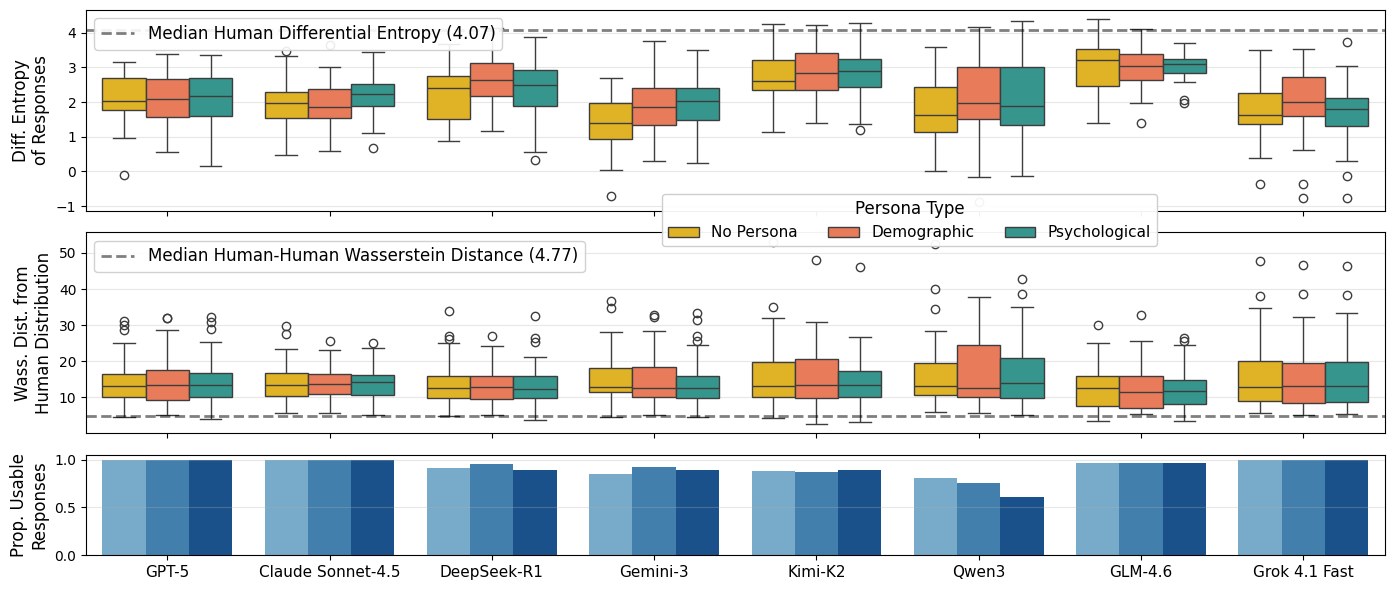

In [245]:
## Unified Plot: Persona Ablation


model_order_pp = ['gpt-5', 'claude-sonnet-4.5', 'DeepSeek-R1', 'gemini-3-pro-preview', 'Kimi-K2-Thinking', 'Qwen3-235B-Thinking', 'GLM-4.6', 'grok-4.1-fast']
model_formatted_name_pp = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4.5': 'Claude Sonnet-4.5',
    'DeepSeek-R1': 'DeepSeek-R1',
    'gemini-3-pro-preview': 'Gemini-3',
    'Kimi-K2-Thinking': 'Kimi-K2',
    'Qwen3-235B-Thinking': 'Qwen3',
    'GLM-4.6': 'GLM-4.6',
    'grok-4.1-fast': 'Grok 4.1 Fast'
}

# Prepare data
persona_prompting_models = [x for x in joint_persona_prompting_ablation_df['source'].unique() if x != 'human']
model_data_only_pp = joint_persona_prompting_ablation_df[joint_persona_prompting_ablation_df['source'] != 'human'].copy()

# Map model names to formatted names
model_data_only_pp['source'] = model_data_only_pp['source'].map(model_formatted_name_pp)
model_order_formatted_pp = [model_formatted_name_pp[m] for m in model_order_pp]

# Create grouped data for entropy and wasserstein
grouped_data_pp = model_data_only_pp.groupby(['source', 'persona_type', 'UID']).agg({
    'diff_entropy_response': 'first',
    'wasserstein_distance_from_human': 'first'
}).reset_index()

# Define formatted persona type names
persona_type_formatted_name = {
    'psychological': 'Psychological',
    'demographic': 'Demographic',
    'no_persona': 'No Persona'
}

# Map persona_type to formatted names in the grouped data
grouped_data_pp['persona_type'] = grouped_data_pp['persona_type'].map(persona_type_formatted_name)

# Calculate median human differential entropy for the horizontal line
human_data_pp = joint_persona_prompting_ablation_df[joint_persona_prompting_ablation_df['source'] == 'human']
median_human_entropy_pp = human_data_pp['diff_entropy_response'].median()

# Calculate proportion usable data for each model-persona_type combination
usable_data_dict_pp = {}
for model in persona_prompting_models:
    model_data = joint_persona_prompting_ablation_df[joint_persona_prompting_ablation_df['source'] == model]
    formatted_model = model_formatted_name_pp[model]
    for persona_type in ['no_persona', 'demographic', 'psychological']:
        pp_data = model_data[model_data['persona_type'] == persona_type]
        if len(pp_data) > 0:
            prop_usable = np.mean(~pd.isna(pp_data['response']))
            usable_data_dict_pp[(formatted_model, persona_type)] = prop_usable

# Create figure with 3 rows, shared x-axis, with custom height ratios
fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, 
                        gridspec_kw={'height_ratios': [2, 2, 1]})

# Define color palette for persona types: distinct colors (not just shades) - using formatted names
persona_type_colors = {
    'Psychological': '#26A69A',      # Teal
    'Demographic': '#FF7043',        # Coral
    'No Persona': '#FFC107'          # Gold/Amber
}

# Row 1: Entropy boxplots
sns.boxplot(data=grouped_data_pp, y='diff_entropy_response', x='source', 
            hue='persona_type', hue_order=['No Persona', 'Demographic', 'Psychological'],
            order=model_order_formatted_pp,
            ax=axs[0], palette=persona_type_colors)
human_line_pp = axs[0].axhline(y=median_human_entropy_pp, color='black', linestyle='--', 
                                linewidth=2, alpha=0.5)
axs[0].set_ylabel('Diff. Entropy\nof Responses', fontsize=12)
axs[0].set_xlabel('')
# Create custom legend with only the human median line
axs[0].legend([human_line_pp], [f'Median Human Differential Entropy ({median_human_entropy_pp:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[0].grid(axis='y', alpha=0.3)

# Row 2: Wasserstein distance boxplots
sns.boxplot(data=grouped_data_pp, y='wasserstein_distance_from_human', x='source', 
            hue='persona_type', hue_order=['No Persona', 'Demographic', 'Psychological'],
            order=model_order_formatted_pp,
            ax=axs[1], palette=persona_type_colors)
human_line_wasserstein = axs[1].axhline(y=median_human_validation_wasserstein_distance, color='black', linestyle='--', 
                             linewidth=2, alpha=0.5)
axs[1].set_ylabel('Wass. Dist. from\nHuman Distribution', fontsize=12)
axs[1].set_xlabel('')
axs[1].legend([human_line_wasserstein], [f'Median Human-Human Wasserstein Distance ({median_human_validation_wasserstein_distance:.2f})'], 
              loc='upper left', fontsize=12, framealpha=0.9)
axs[1].grid(axis='y', alpha=0.3)

# Row 3: Proportion usable data bars
usable_data_list_pp = []
for model in persona_prompting_models:
    formatted_model = model_formatted_name_pp[model]
    for persona_type in ['no_persona', 'demographic', 'psychological']:
        if (formatted_model, persona_type) in usable_data_dict_pp:
            usable_data_list_pp.append({
                'source': formatted_model,
                'persona_type': persona_type_formatted_name[persona_type],
                'proportion_usable': usable_data_dict_pp[(formatted_model, persona_type)]
            })
usable_data_df_pp = pd.DataFrame(usable_data_list_pp)

# Create a blue gradient palette for the bottom plot using formatted names
blue_gradient_palette_pp = {
    'Psychological': '#08519c',      # Dark blue
    'Demographic': '#3182bd',        # Medium blue
    'No Persona': '#6baed6'          # Light blue
}

sns.barplot(data=usable_data_df_pp, x='source', y='proportion_usable', 
            hue='persona_type', hue_order=['No Persona', 'Demographic', 'Psychological'],
            order=model_order_formatted_pp,
            ax=axs[2], palette=blue_gradient_palette_pp, width=0.8)
axs[2].set_ylabel('Prop. Usable\nResponses', fontsize=12)
axs[2].set_xlabel('', fontsize=12)
axs[2].set_ylim(0, 1.05)
axs[2].grid(axis='y', alpha=0.3)
axs[2].legend_.remove()

# Rotate x-axis labels for bottom plot
axs[2].set_xticklabels(axs[2].get_xticklabels(), rotation=0, ha='center', fontsize=11)

# Add persona type legend between top and middle rows
handles, labels = axs[1].get_legend_handles_labels()
legend = fig.legend(handles, labels, title='Persona Type', 
                    bbox_to_anchor=(0.65, 0.625), loc='center', 
                    ncol=3, fontsize=11, title_fontsize=12, framealpha=0.95, 
                    bbox_transform=fig.transFigure)

plt.tight_layout()
plt.savefig('./plots/unified_persona_prompting_ablation.pdf', bbox_inches='tight', dpi=300)
plt.show()

## What's happening with Claude Opus-4.6? (Table 3)

In [246]:
opus_4_6_results_df_list = []
for reasoning_effort in ['low', 'medium', 'high']:
    reasoning_effort_results_df = pd.read_json(f"./results/claude-opus-4.6_reasoning_effort_{reasoning_effort}.jsonl", lines=True)
    reasoning_effort_results_df['reasoning_effort'] = reasoning_effort
    opus_4_6_results_df_list.append(reasoning_effort_results_df)

opus_4_6_results_df = pd.concat(opus_4_6_results_df_list).reset_index(drop=True)

opus_4_6_results_df['response'] = opus_4_6_results_df['answer'].apply(attempt_digit_conversion)
opus_4_6_results_df['median_response'] = opus_4_6_results_df.groupby(['UID'])['response'].transform('median')
opus_4_6_results_df['source'] = 'claude-opus-4.6'

/var/folders/mc/31s8zfz52gbby2mcz4vdb8f40000gn/T/ipykernel_38487/1981843732.py:3: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  reasoning_effort_results_df = pd.read_json(f"./results/claude-opus-4.6_reasoning_effort_{reasoning_effort}.jsonl", lines=True)


ValueError: Expected object or value

In [ ]:
# Opus-4.6: Literally print responses for each UID:
print("=" * 50)
print("CLAUDE OPUS-4.6 ANALYSIS")
print("=" * 50)
print("--------------------------------------------")
print("Keys: unique model responses for each UID\nValues: counts of each unique response")
print("--------------------------------------------\n")
for UID in opus_4_6_results_df['UID'].unique():
    UID_indexed = opus_4_6_results_df[opus_4_6_results_df['UID'] == UID]
    low_effort_UID_indexed = UID_indexed[UID_indexed['reasoning_effort'] == 'low']
    medium_effort_UID_indexed = UID_indexed[UID_indexed['reasoning_effort'] == 'medium']
    high_effort_UID_indexed = UID_indexed[UID_indexed['reasoning_effort'] == 'high']
    low_effort_responses_unique = low_effort_UID_indexed['response'].value_counts()
    medium_effort_responses_unique = medium_effort_UID_indexed['response'].value_counts()
    high_effort_responses_unique = high_effort_UID_indexed['response'].value_counts()
    print(f"UID: {UID}")
    print(f"Low Effort Responses: {low_effort_responses_unique.to_dict()}")
    print(f"Medium Effort Responses: {medium_effort_responses_unique.to_dict()}")
    print(f"High Effort Responses: {high_effort_responses_unique.to_dict()}")
    print("--------------------------------\n")

CLAUDE OPUS-4.6 ANALYSIS
--------------------------------------------
Keys: unique model responses for each UID
Values: counts of each unique response
--------------------------------------------

UID: 11
Low Effort Responses: {20.0: 30}
Medium Effort Responses: {20.0: 30}
High Effort Responses: {20.0: 30}
--------------------------------

UID: 21
Low Effort Responses: {5.0: 22, 8.0: 8}
Medium Effort Responses: {8.0: 30}
High Effort Responses: {8.0: 17, 5.0: 9, 10.0: 4}
--------------------------------

UID: 25
Low Effort Responses: {55.0: 29, 45.0: 1}
Medium Effort Responses: {55.0: 29, 50.0: 1}
High Effort Responses: {55.0: 23, 50.0: 7}
--------------------------------

UID: 28
Low Effort Responses: {95.0: 30}
Medium Effort Responses: {95.0: 30}
High Effort Responses: {95.0: 30}
--------------------------------

UID: 37
Low Effort Responses: {72.0: 30}
Medium Effort Responses: {72.0: 30}
High Effort Responses: {72.0: 29, 75.0: 1}
--------------------------------

UID: 43
Low Effort R

In [ ]:
# Opus-4.6: How often do we get reasoning chains at all?
print("=" * 50)
print("CLAUDE OPUS-4.6 - REASONING CHAIN ANALYSIS")
print("=" * 50)

for UID in opus_4_6_results_df['UID'].unique():
    UID_indexed = opus_4_6_results_df[opus_4_6_results_df['UID'] == UID]
    print(f"UID: {UID}")
    for reasoning_effort in ['low', 'medium', 'high']:
        reasoning_effort_UID_indexed = UID_indexed[UID_indexed['reasoning_effort'] == reasoning_effort]
        unique_reasoning_chain_lengths = reasoning_effort_UID_indexed['reasoning_token_count'].value_counts().to_dict()
        proportion_reasoning_chains_non_null = np.mean(reasoning_effort_UID_indexed['summary'].notna())
        print(f"Reasoning Effort {reasoning_effort}: Unique Reasoning Chain Lengths: {unique_reasoning_chain_lengths}, Proportion Reasoning Chains Non-Null: {proportion_reasoning_chains_non_null}")
    print("--------------------------------\n")


CLAUDE OPUS-4.6 - REASONING CHAIN ANALYSIS
UID: 11
Reasoning Effort low: Unique Reasoning Chain Lengths: {10: 30}, Proportion Reasoning Chains Non-Null: 0.0
Reasoning Effort medium: Unique Reasoning Chain Lengths: {10: 30}, Proportion Reasoning Chains Non-Null: 0.0
Reasoning Effort high: Unique Reasoning Chain Lengths: {10: 30}, Proportion Reasoning Chains Non-Null: 0.0
--------------------------------

UID: 21
Reasoning Effort low: Unique Reasoning Chain Lengths: {10: 30}, Proportion Reasoning Chains Non-Null: 0.0
Reasoning Effort medium: Unique Reasoning Chain Lengths: {10: 30}, Proportion Reasoning Chains Non-Null: 0.0
Reasoning Effort high: Unique Reasoning Chain Lengths: {127: 3, 115: 3, 119: 3, 117: 2, 106: 2, 116: 1, 104: 1, 102: 1, 121: 1, 112: 1, 134: 1, 113: 1, 103: 1, 96: 1, 132: 1, 110: 1, 122: 1, 123: 1, 129: 1, 100: 1, 155: 1, 118: 1}, Proportion Reasoning Chains Non-Null: 1.0
--------------------------------

UID: 25
Reasoning Effort low: Unique Reasoning Chain Lengths: 

Note: For Anthropic models, we use the total number of output tokens as a proxy for the 'reasoning token count', since only reasoning chain summaries are provided (rather than the reasoning chains themselves; the API also does not provide separate reasoning token and output token counts in its outputs). With Opus-4.6, we see that the number of output tokens is almost always 10, suggesting there may be a fixed reasoning chain or output template being used here. 

In [ ]:
## Opus-4.6: Compile things overall
print("=" * 50)
print("CLAUDE OPUS-4.6 - SUMMARY TABLE")
print("=" * 50)

summary_rows_opus = []
for reasoning_effort in ['low', 'medium', 'high']:
    effort_df = opus_4_6_results_df[opus_4_6_results_df['reasoning_effort'] == reasoning_effort]
    prop_10_tokens = np.mean(effort_df['reasoning_token_count'] == 10)
    prop_non_empty_summary = np.mean(effort_df['summary'].notna())
    range_rc_lengths = f"{effort_df['reasoning_token_count'].min()} - {effort_df['reasoning_token_count'].max()}"
    diff_entropy_of_responses = effort_df.groupby(['UID'])['response'].transform(estimate_differential_entropy).mean()
    median_n_unique_responses = effort_df.groupby(['UID'])['response'].nunique().median()
    summary_rows_opus.append({
        'Reasoning Effort': reasoning_effort,
#        'Prop. Responses where No. Output Tokens = 10': round(prop_10_tokens, 3),
        'Prop. non-Empty Reasoning Chain Summaries': round(prop_non_empty_summary, 3),
        'Range of Reasoning Chain Lengths': range_rc_lengths,
        'Diff. Entropy of Responses': round(diff_entropy_of_responses, 3),
        'Median Number of Unique Responses': median_n_unique_responses
    })

summary_df_opus = pd.DataFrame(summary_rows_opus)
summary_df_opus

CLAUDE OPUS-4.6 - SUMMARY TABLE


,Reasoning Effort,Prop. non-Empty Reasoning Chain Summaries,Range of Reasoning Chain Lengths,Diff. Entropy of Responses,Median Number of Unique Responses
0,low,0.000,10 - 10,-0.486,1.0
1,medium,0.000,10 - 10,-0.667,1.0
2,high,0.198,10 - 250,-0.296,1.0
